1) Brief description of the data set and a summary of its attributes

2) Initial plan for data exploration

3) Actions taken for data cleaning and feature engineering

4) Key Findings and Insights, which synthesizes the results of Exploratory Data Analysis in an insightful and actionable manner

5) Formulating at least 3 hypothesis about this data

6) Conducting a formal significance test for one of the hypotheses and discuss the results 

7) Suggestions for next steps in analyzing this data

8) A paragraph that summarizes the quality of this data set and a request for additional data if needed

# Engineering Graduate Salary Prediction

India has a total 6,214 Engineering and Technology Institutions in which around 2.9 million students are enrolled. Every year, on an average 1.5 million students get their degree in engineering, but due to lack of skill required to perform technical jobs less than 20% get employment in their core domain.

A relevant question is what determines the salary and the jobs these engineers are offered right after graduation. Various factors such as college grades, candidate skills, the proximity of the college to industrial hubs, the specialization one have, market conditions for specific industries determine this. On the basis of these various factors, your objective is to determine the salary of an engineering graduate in India.

Source:
https://www.kaggle.com/datasets/manishkc06/engineering-graduate-salary-prediction

### Data 

**ID**: A unique ID to identify a candidate \
**Salary**: Annual CTC offered to the candidate (in INR) \
**Gender**: Candidate's gender \
**DOB**: Date of birth of the candidate \
**10percentage**: Overall marks obtained in grade 10 examinations \
**10board**: The school board whose curriculum the candidate followed in grade 10 \
**12graduation**: Year of graduation - senior year high school \
**12percentage**: Overall marks obtained in grade 12 examinations \
**12board**: The school board whose curriculum the candidate followed \
**CollegeID**: Unique ID identifying the university/college which the candidate attended for her/his undergraduate \
**CollegeTier**: Each college has been annotated as 1 or 2. The annotations have been computed from the average AMCAT scores obtained by the students in the college/university. Colleges with an average score above a threshold are tagged as 1 and others as 2. \
**Degree**: Degree obtained/pursued by the candidate \
**Specialization**: Specialization pursued by the candidate \
**CollegeGPA**: Aggregate GPA at graduation \ 
**CollegeCityID**: A unique ID to identify the city in which the college is located in. \
**CollegeCityTier**: The tier of the city in which the college is located in. This is annotated based on the population of the cities. \
**CollegeState**: Name of the state in which the college is located \
**GraduationYear**: Year of graduation (Bachelor's degree) \
**English**: Scores in AMCAT English section \
**Logical**: Score in AMCAT Logical ability section \
**Quant**: Score in AMCAT's Quantitative ability section \
**Domain**: Scores in AMCAT's domain module \
**ComputerProgramming**: Score in AMCAT's Computer programming section \
**ElectronicsAndSemicon**: Score in AMCAT's Electronics & Semiconductor Engineering section \
**ComputerScience**: Score in AMCAT's Computer Science section \
**MechanicalEngg**: Score in AMCAT's Mechanical Engineering section \
**ElectricalEngg**: Score in AMCAT's Electrical Engineering section \
**TelecomEngg**: Score in AMCAT's Telecommunication Engineering section \
**CivilEngg**: Score in AMCAT's Civil Engineering section \
**conscientiousness**: Scores in one of the sections of AMCAT's personality test \
**agreeableness**: Scores in one of the sections of AMCAT's personality test \
**extraversion**: Scores in one of the sections of AMCAT's personality test \
**nueroticism**: Scores in one of the sections of AMCAT's personality test \
**openess_to_experience**: Scores in one of the sections of AMCAT's personality test \

## Import the Required Library

In [61]:
import warnings 
warnings.filterwarnings('ignore')

In [93]:
#import library that might be in use

import pandas as pd
import numpy as np 
import math

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

from scipy.stats import norm
from scipy.stats import skew
from scipy.stats import boxcox
from scipy.stats import yeojohnson
from scipy import stats

## Reading and Understanding Our Data

In [63]:
#import data
df = pd.read_csv('Engineering_graduate_salary.csv', sep=',')

In [64]:
#A brief look of the data
df.head()

,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,...,-1,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,...,-1,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,...,-1,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,...,-1,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,...,-1,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2998 entries, 0 to 2997
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2998 non-null   int64  
 1   Gender                 2998 non-null   object 
 2   DOB                    2998 non-null   object 
 3   10percentage           2998 non-null   float64
 4   10board                2998 non-null   object 
 5   12graduation           2998 non-null   int64  
 6   12percentage           2998 non-null   float64
 7   12board                2998 non-null   object 
 8   CollegeID              2998 non-null   int64  
 9   CollegeTier            2998 non-null   int64  
 10  Degree                 2998 non-null   object 
 11  Specialization         2998 non-null   object 
 12  collegeGPA             2998 non-null   float64
 13  CollegeCityID          2998 non-null   int64  
 14  CollegeCityTier        2998 non-null   int64  
 15  Coll

We can see that there is no missing values in every feature because they all have 2998 non-null count which is the same amount as the total entries

In [66]:
df.describe()

,ID,10percentage,12graduation,12percentage,CollegeID,CollegeTier,collegeGPA,CollegeCityID,CollegeCityTier,GraduationYear,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
count,2.998000e+03,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,...,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2.998000e+03
mean,6.648926e+05,77.666264,2008.080720,74.341061,5210.210807,1.924616,71.509857,5210.210807,0.296197,2011.939960,...,24.138759,16.267845,31.068379,1.946965,-0.038714,0.126217,-0.008662,-0.145965,-0.141111,3.051748e+05
std,3.648951e+05,10.002785,1.631814,11.120299,4776.609877,0.264053,8.122462,4776.609877,0.456655,36.780582,...,99.785138,86.054739,103.552963,32.241501,1.024974,0.955831,0.962695,1.012901,1.007134,2.123312e+05
min,1.124400e+04,43.000000,1998.000000,40.000000,2.000000,1.000000,6.630000,2.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-3.893300,-5.781600,-4.600900,-2.643000,-7.375700,3.500000e+04
25%,3.334648e+05,71.140000,2007.000000,66.000000,526.250000,2.000000,66.530000,526.250000,0.000000,2012.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-0.649100,-0.435300,-0.604800,-0.868200,-0.669200,1.800000e+05
50%,6.396945e+05,78.965000,2008.000000,74.000000,4027.500000,2.000000,71.800000,4027.500000,0.000000,2013.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.046400,0.212400,0.091400,-0.172700,-0.094300,3.000000e+05
75%,9.951770e+05,85.600000,2009.000000,82.600000,8822.250000,2.000000,76.300000,8822.250000,1.000000,2014.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.702700,0.812800,0.672000,0.526200,0.502400,3.700000e+05
max,1.297877e+06,97.760000,2012.000000,98.700000,18409.000000,2.000000,99.930000,18409.000000,1.000000,2017.000000,...,623.000000,660.000000,548.000000,500.000000,1.995300,1.904800,2.161700,3.352500,1.630200,4.000000e+06


In [67]:
stats_df = df.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['count', 'mean', 'std', '25%','50%','75%', 'min', 'max', 'range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df

,ID,10percentage,12graduation,12percentage,CollegeID,CollegeTier,collegeGPA,CollegeCityID,CollegeCityTier,GraduationYear,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
count,2.998000e+03,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,...,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2.998000e+03
mean,6.648926e+05,77.666264,2008.080720,74.341061,5210.210807,1.924616,71.509857,5210.210807,0.296197,2011.939960,...,24.138759,16.267845,31.068379,1.946965,-0.038714,0.126217,-0.008662,-0.145965,-0.141111,3.051748e+05
std,3.648951e+05,10.002785,1.631814,11.120299,4776.609877,0.264053,8.122462,4776.609877,0.456655,36.780582,...,99.785138,86.054739,103.552963,32.241501,1.024974,0.955831,0.962695,1.012901,1.007134,2.123312e+05
25%,3.334648e+05,71.140000,2007.000000,66.000000,526.250000,2.000000,66.530000,526.250000,0.000000,2012.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-0.649100,-0.435300,-0.604800,-0.868200,-0.669200,1.800000e+05
median,6.396945e+05,78.965000,2008.000000,74.000000,4027.500000,2.000000,71.800000,4027.500000,0.000000,2013.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.046400,0.212400,0.091400,-0.172700,-0.094300,3.000000e+05
75%,9.951770e+05,85.600000,2009.000000,82.600000,8822.250000,2.000000,76.300000,8822.250000,1.000000,2014.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.702700,0.812800,0.672000,0.526200,0.502400,3.700000e+05
min,1.124400e+04,43.000000,1998.000000,40.000000,2.000000,1.000000,6.630000,2.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-3.893300,-5.781600,-4.600900,-2.643000,-7.375700,3.500000e+04
max,1.297877e+06,97.760000,2012.000000,98.700000,18409.000000,2.000000,99.930000,18409.000000,1.000000,2017.000000,...,623.000000,660.000000,548.000000,500.000000,1.995300,1.904800,2.161700,3.352500,1.630200,4.000000e+06
range,1.286633e+06,54.760000,14.000000,58.700000,18407.000000,1.000000,93.300000,18407.000000,1.000000,2017.000000,...,624.000000,661.000000,549.000000,501.000000,5.888600,7.686400,6.762600,5.995500,9.005900,3.965000e+06


## Handling the Duplicates

In [68]:
#Check if there is any duplicate in our dataframe
df['ID'].duplicated().sum()

np.int64(0)

In [69]:
df.ID.is_unique

True

In [70]:
df.index.is_unique

True


## Handling the Missing Values 

Text(0.5, 1.0, 'Total Missing Values')

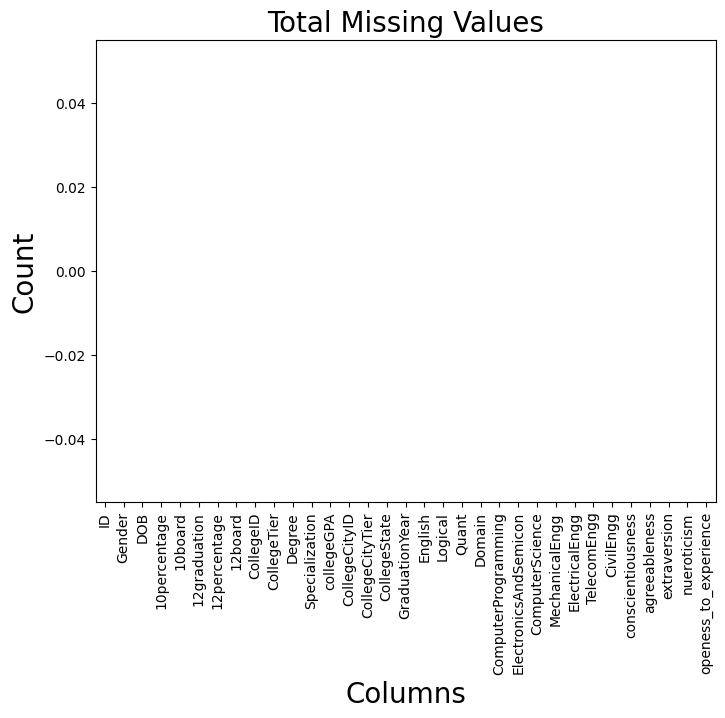

In [71]:
total = df.isnull().sum().sort_values(ascending=False)
total_select = total.head(33)
total_select.plot(kind="bar", figsize = (8,6), fontsize = 10)

plt.xlabel("Columns", fontsize = 20)
plt.ylabel("Count", fontsize = 20)
plt.title("Total Missing Values", fontsize = 20)

The empty figure confirms that there are no missing values

## Feature Selection 

We will get rid of some irrelevant columns that do not affect salaries, such as 'ID', 'DOB', '10board', '12board' and so on

In [72]:
df1 = df.drop(['ID', 'DOB', 'CollegeID', '12graduation' ,'GraduationYear','10board', '12board' , 'CollegeState','CollegeCityID', 
              'CollegeCityTier'], axis = 1)
df1.head()

,Gender,10percentage,12percentage,CollegeTier,Degree,Specialization,collegeGPA,English,Logical,Quant,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,f,87.80,84.00,1,B.Tech/B.E.,instrumentation and control engineering,73.82,650,665,810,...,-1,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,m,57.00,64.50,2,B.Tech/B.E.,computer science & engineering,65.00,440,435,210,...,-1,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,m,77.33,85.17,2,B.Tech/B.E.,electronics & telecommunications,61.94,485,475,505,...,-1,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,m,84.30,86.00,1,B.Tech/B.E.,computer science & engineering,80.40,675,620,635,...,-1,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,f,82.00,75.00,2,B.Tech/B.E.,biotechnology,64.30,575,495,365,...,-1,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000


In [73]:
#Check if there is any duplicate in our dataframe
df1.duplicated().sum()

np.int64(0)

In [74]:
spec_counts = df1.Specialization.value_counts()
spec_counts

Specialization
electronics and communication engineering      670
computer science & engineering                 557
information technology                         506
computer engineering                           415
computer application                           201
mechanical engineering                         155
electronics and electrical engineering         148
electronics & telecommunications                89
electrical engineering                          63
electronics & instrumentation eng               24
electronics and instrumentation engineering     18
information science engineering                 18
instrumentation and control engineering         18
civil engineering                               15
electronics engineering                         13
biotechnology                                   12
other                                           10
industrial & production engineering              8
chemical engineering                             7
mechanical and a

We will include Specialization that occupied by less than 10 graduates into one 'Other' category. Because a lot of single values can unnecessarily affect the model if we try to train it using this data. We can group those data together since they're not adding much value to the 'information' as a whole

In [75]:
others_spec = list(spec_counts[spec_counts <= 10].index)

df2 = df1.copy()

df2['Specialization'] = df1['Specialization'].replace(others_spec, 'Others')

df2.Specialization.value_counts()

Specialization
electronics and communication engineering      670
computer science & engineering                 557
information technology                         506
computer engineering                           415
computer application                           201
mechanical engineering                         155
electronics and electrical engineering         148
electronics & telecommunications                89
Others                                          76
electrical engineering                          63
electronics & instrumentation eng               24
instrumentation and control engineering         18
information science engineering                 18
electronics and instrumentation engineering     18
civil engineering                               15
electronics engineering                         13
biotechnology                                   12
Name: count, dtype: int64

## Handling the Outliers 

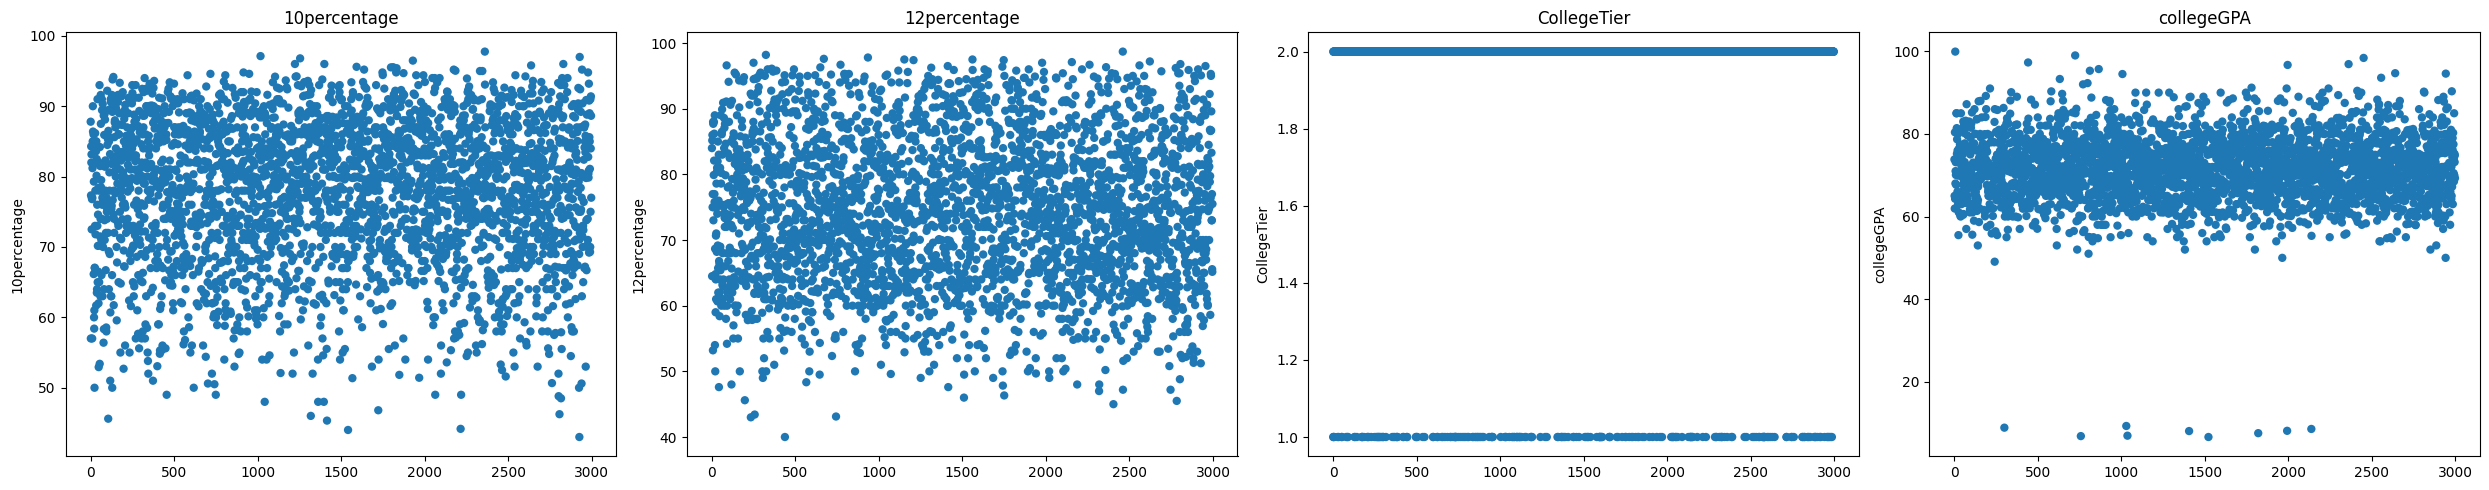

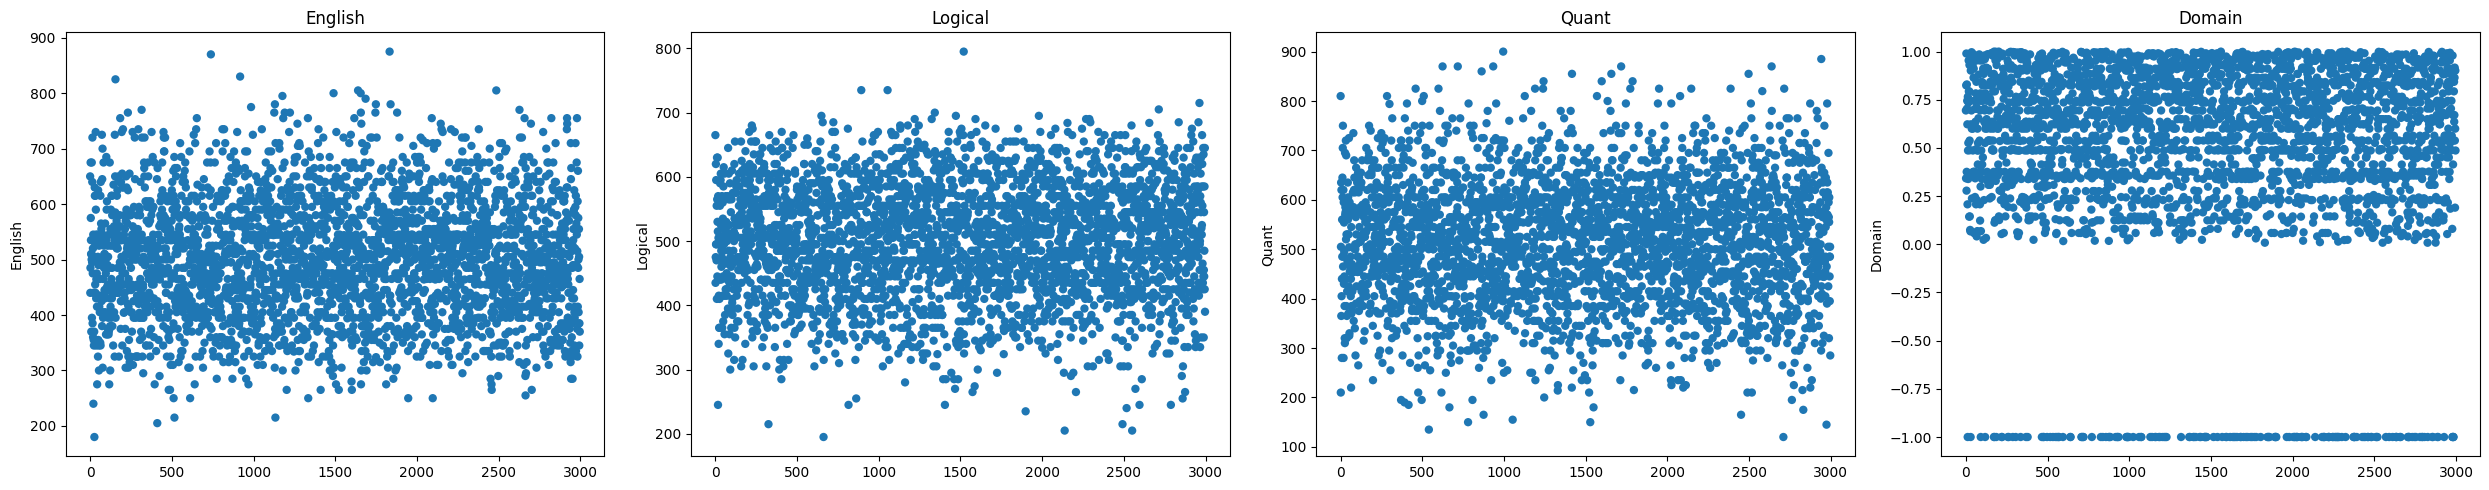

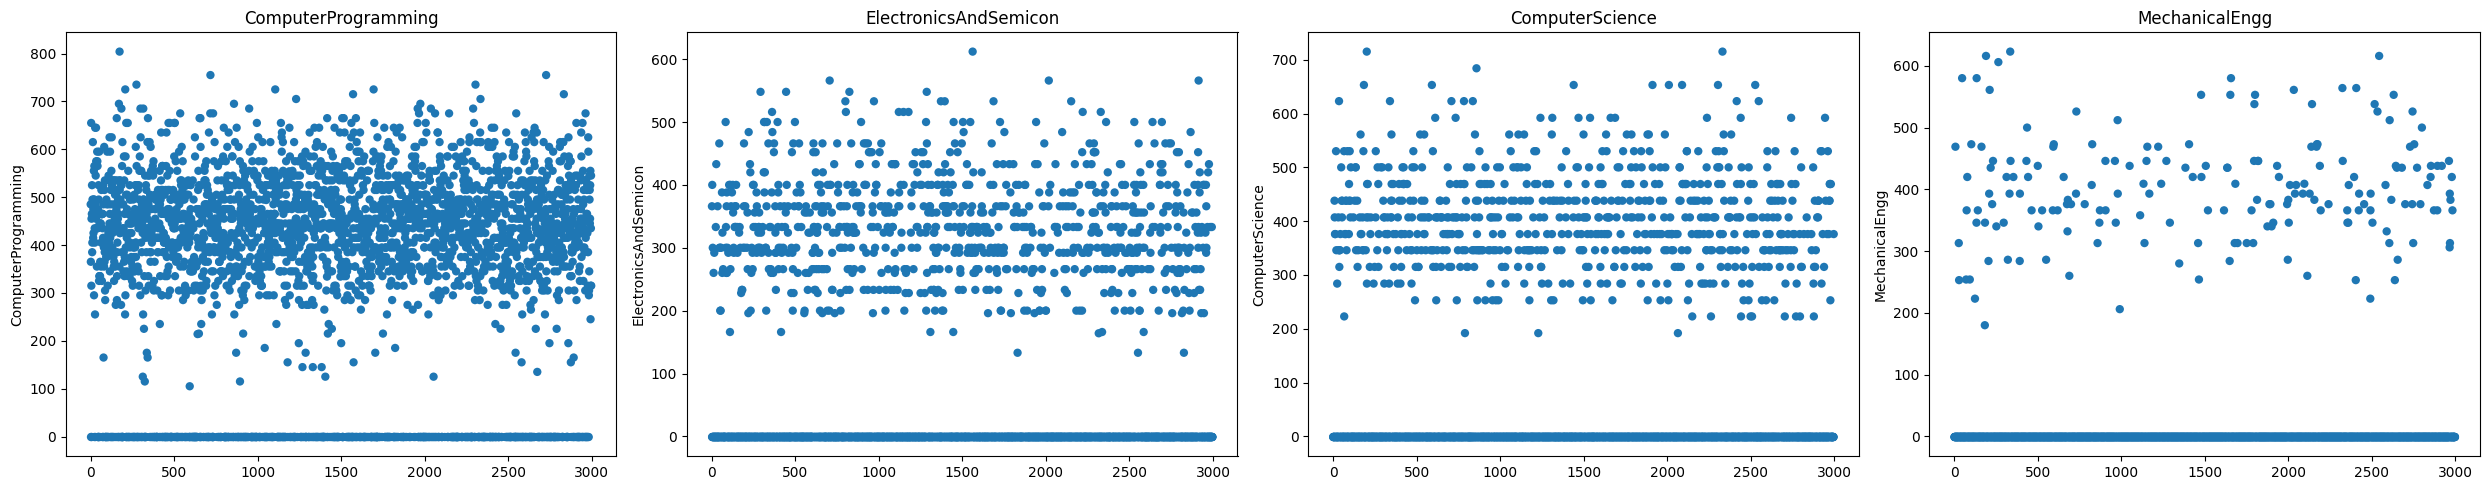

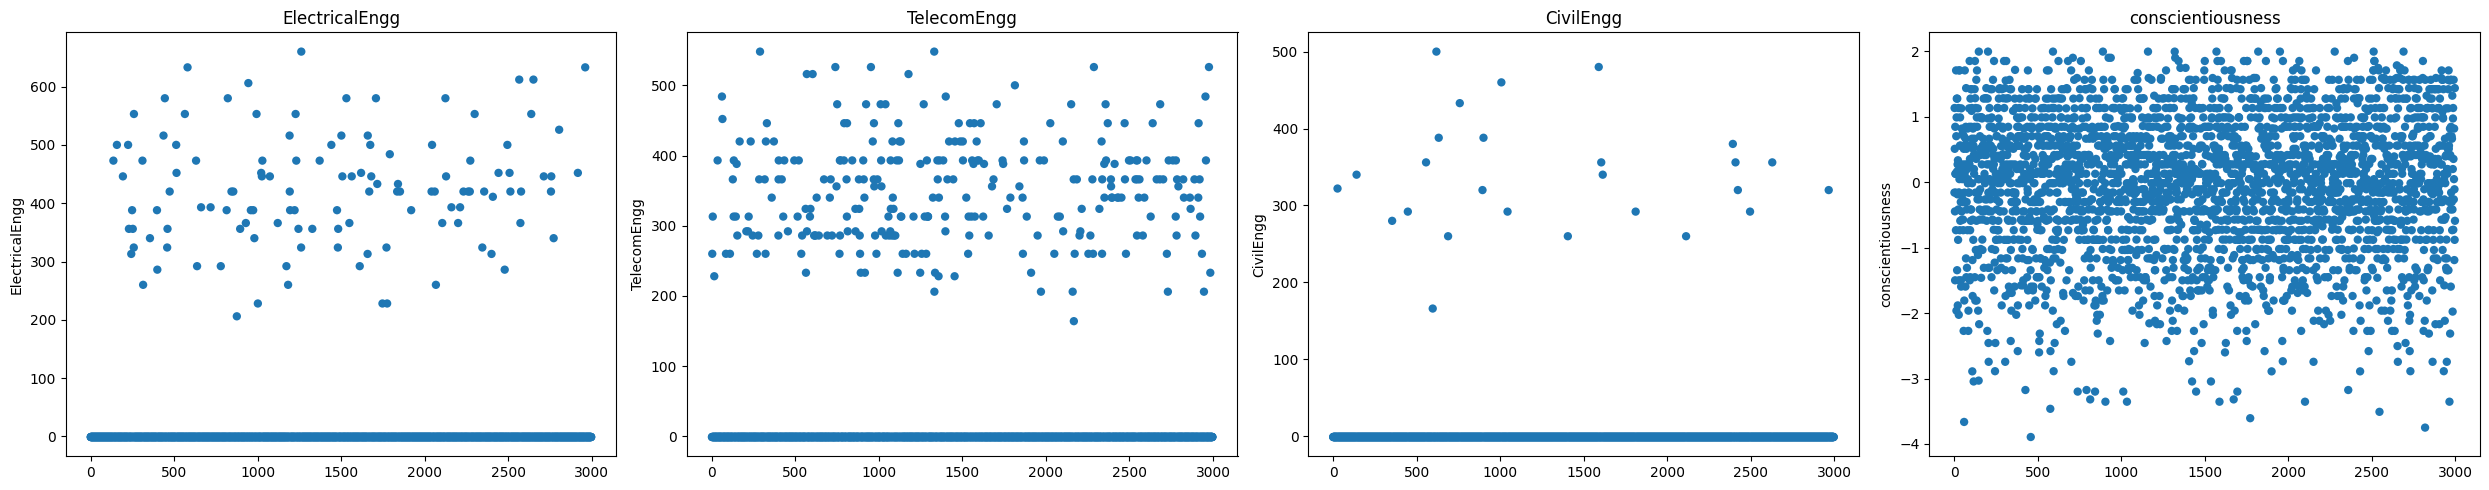

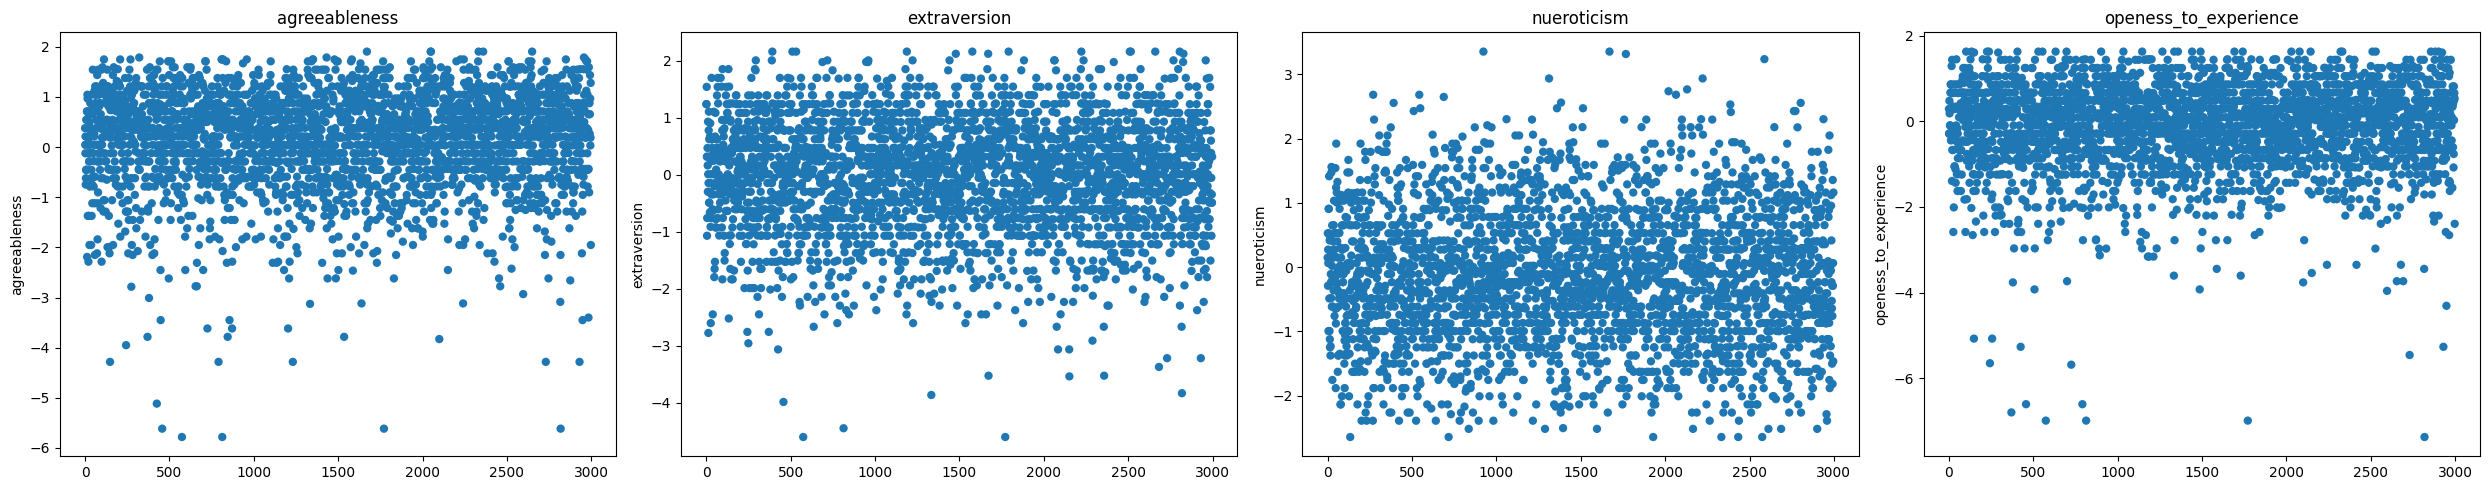

In [77]:
df2_num = df2.select_dtypes(include = ['float64', 'int64'])
df2_dist = df2_num.drop("Salary", axis=1)

for i in range(0, len(df2_dist.columns), 4):
    fig, axes = plt.subplots(1, 4, figsize=(25, 5))
    
    for j, col in enumerate(df2_dist.columns[i:i+4]):
        sns.scatterplot(x=df2_dist.index, y=df2_dist[col], ax=axes[j], edgecolor="None")
        axes[j].set_title(col, fontsize=12)
        axes[j].set_xlabel(None)

    plt.tight_layout()
    plt.show()

From the plots above, we can visually detect outliers in collegeGPA attribute and several attributes of AMCAT section test such as Domain, ComputerProgramming, ElectronicsAndSemicon, ComputerScience, MechanicalEngg, ElectricalEngg, TelecomEngg, and CivilEngg.

First, we will try to get rid of the outliers of collegeGPA using Uni-variate analysis (box plot). Therefore, let's see first the collegeGPA distribution in a boxplot chart.

<Axes: xlabel='collegeGPA'>

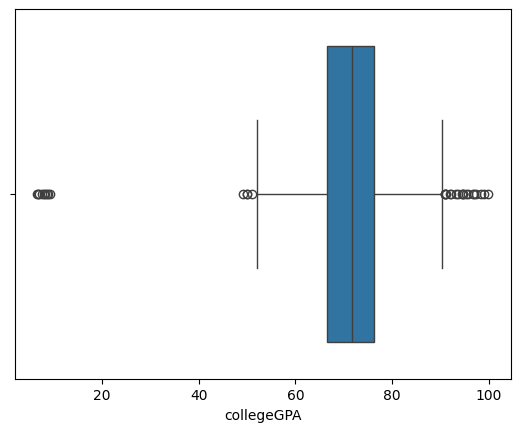

In [78]:
sns.boxplot(x=df2['collegeGPA'])

The boxplot clearly shows that the values mostly lie in 50–100 range and we can safely drop values less than 20 which can produce unnecessary bias. Or in the other way, only include GPA > 40

<Axes: xlabel='collegeGPA'>

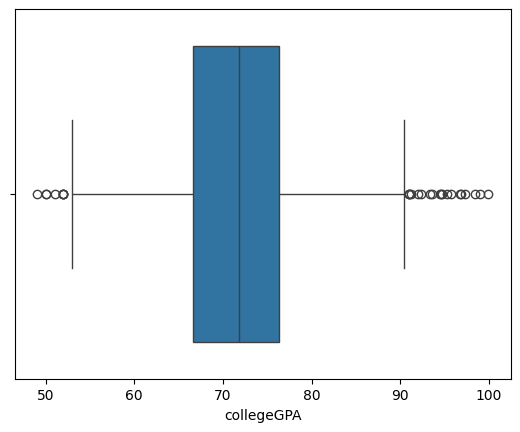

In [79]:
df2 = df2[(df2['collegeGPA'] > 40)]
sns.boxplot(x=df2['collegeGPA'])

From the distribution plots above, we can see that there are outliers in attributes such as Domain, ComputerProgramming, ElectronicsAndSemicon, ComputerScience, MechanicalEngg, TelecomEngg, and CivilEngg. These represent scores of sections in the AMCAT test.

In the AMCAT test, it is not possible to obtain a negative score in exam-type tests (though it is possible for personality-type tests like Agreeableness, Neuroticism, Openness to Experience, etc.). Therefore, the presence of negative values suggests two possibilities:

1. Data entry or processing errors.
2. Indicators that students did not take the corresponding section test, since not all subtests are mandatory (e.g., Civil Engineering students may not be required to take the Computer Science subtest).

There are several options to handle these negative values, each with its own trade-off:

1. **Treat as missing values** \
    Replace any score `<0` with `NaN`. \
    Advantages: Keeps dataset consistent, avoids introducing fake values. \
    Disadvantages: Loses the information about why it’s missing.
2. **Create an indicator column** \
    Record a binary flag (e.g., attempted=1, not_attempted=0) while replacing the score with NaN. \
    Advantages: Retains both signals (score + attempted status), useful for predictive modeling. \
    Disadvantages: Increases feature space (more columns).
3. **Drop those columns completely** \
    If a section is largely irrelevant or has too many missing values. \
    Advantages: Simplifies dataset. \
    Disadvantages: Potentially discards valuable predictive information.
4. **Impute negative values with mean/median** \
    Only reasonable if the column has very few missing values, so imputing won't distort things much. \
    Advantages: Avoids losing rows, keeps model input complete. \
    Disadvantages: Can distort distribution; assumes missing = “average,” which may not reflect reality (if majority of data is missing, replacing it would completely fake the data).

In [80]:
cols = ["Domain","ComputerProgramming","ElectronicsAndSemicon",
        "ComputerScience","MechanicalEngg","ElectricalEngg",
        "TelecomEngg","CivilEngg"]

# Step 1: replace negatives with NaN
df2[cols] = df2[cols].mask(df2[cols] < 0)

# Step 2: quick summary (no new columns)
n_total = len(df2)
for col in cols:
    attempted = df2[col].notna().sum()
    not_attempted = df2[col].isna().sum()
    perc_attempted = (attempted / n_total) * 100
    perc_not_attempted = (not_attempted / n_total) * 100
    print(
        f"{col}: "
        f"attempted={attempted} ({perc_attempted:.2f}%), "
        f"not attempted={not_attempted} ({perc_not_attempted:.2f}%)"
    )

Domain: attempted=2810 (94.01%), not attempted=179 (5.99%)
ComputerProgramming: attempted=2342 (78.35%), not attempted=647 (21.65%)
ElectronicsAndSemicon: attempted=864 (28.91%), not attempted=2125 (71.09%)
ComputerScience: attempted=698 (23.35%), not attempted=2291 (76.65%)
MechanicalEngg: attempted=183 (6.12%), not attempted=2806 (93.88%)
ElectricalEngg: attempted=122 (4.08%), not attempted=2867 (95.92%)
TelecomEngg: attempted=274 (9.17%), not attempted=2715 (90.83%)
CivilEngg: attempted=25 (0.84%), not attempted=2964 (99.16%)


For Domain attribute, since there aren't much negative value (only ~6%) we can just impute them with mean value. This method won't create much bias since missing is low and we can preserve nearly the entire dataset.

In [81]:
# Step 1: Replace negatives with NaN
df2["Domain"] = df2["Domain"].mask(df2["Domain"] < 0)

# Step 2: Calculate mean of non-NaN values
domain_mean = df2["Domain"].mean()

# Step 3: Fill NaN (the former negatives) with mean
df2["Domain"] = df2["Domain"].fillna(domain_mean)

Then, as the ComputerProgramming field has around ~22% NaN value, we will now just keep it that way (with the NaN), because ~22% is way too big for imputation.

As for fields of ElectronicsAndSemicon, ComputerScience, MecganicalEngg, ElectricalEngg, TelecomEngg, and CivilEngg, we will drop the columns because the data is too sparse (>= 70% missing)

In [82]:
# Drop sparse columns (>=70% missing)
cols_to_drop = [
    "ElectronicsAndSemicon",
    "ComputerScience",
    "MechanicalEngg",
    "ElectricalEngg",
    "TelecomEngg",
    "CivilEngg"
]

df2 = df2.drop(columns=cols_to_drop)

Now, let's see our new data distribution.

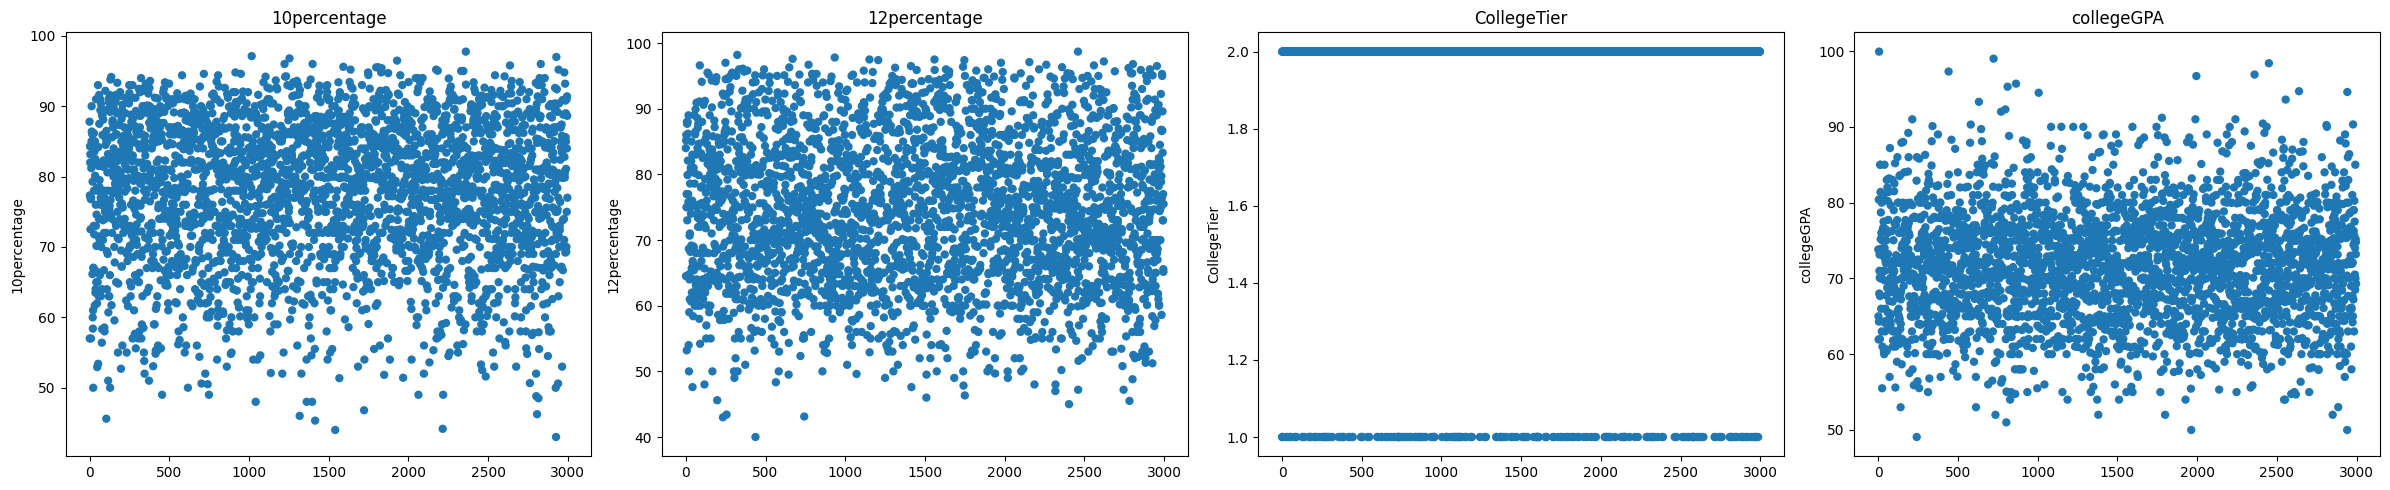

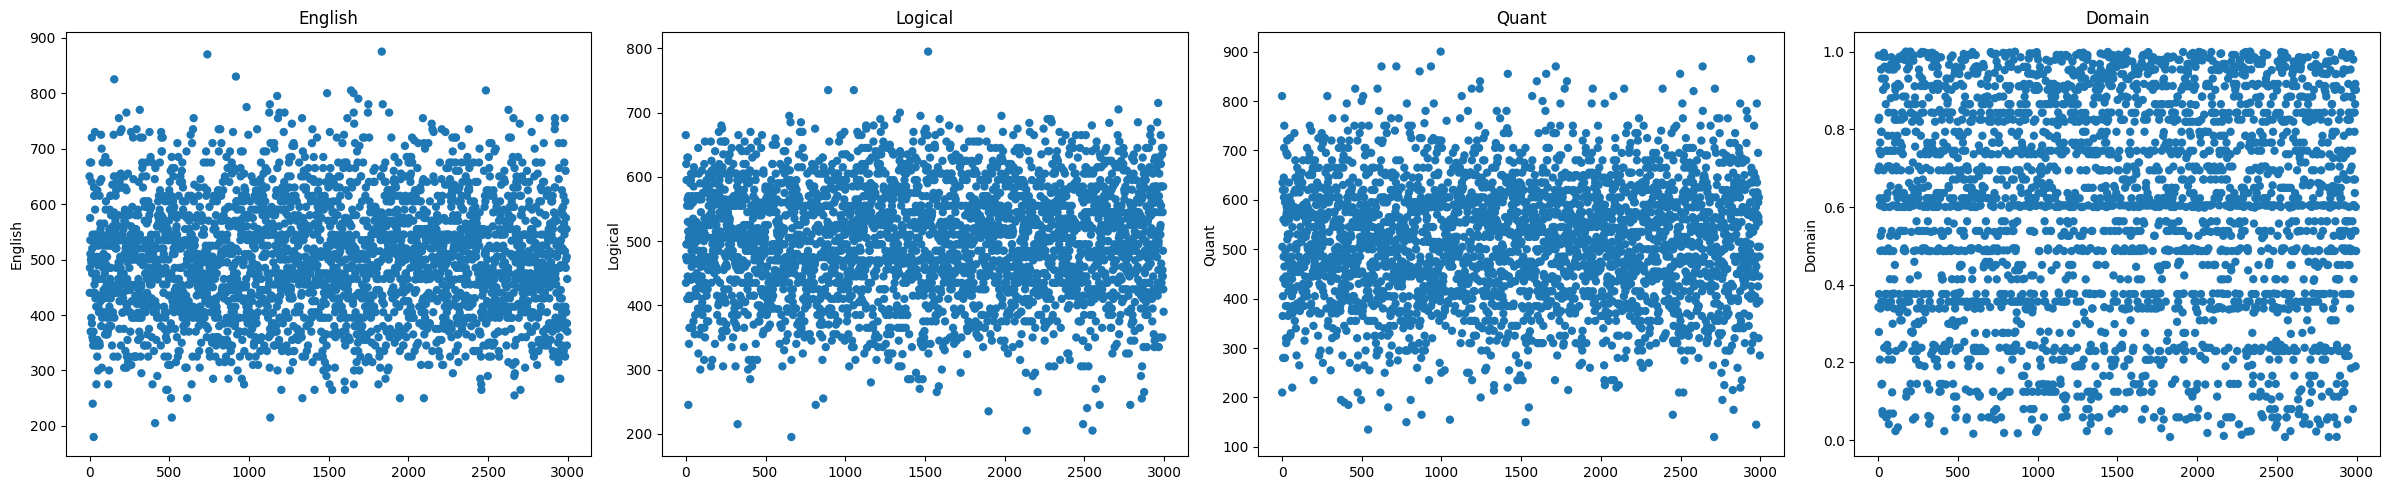

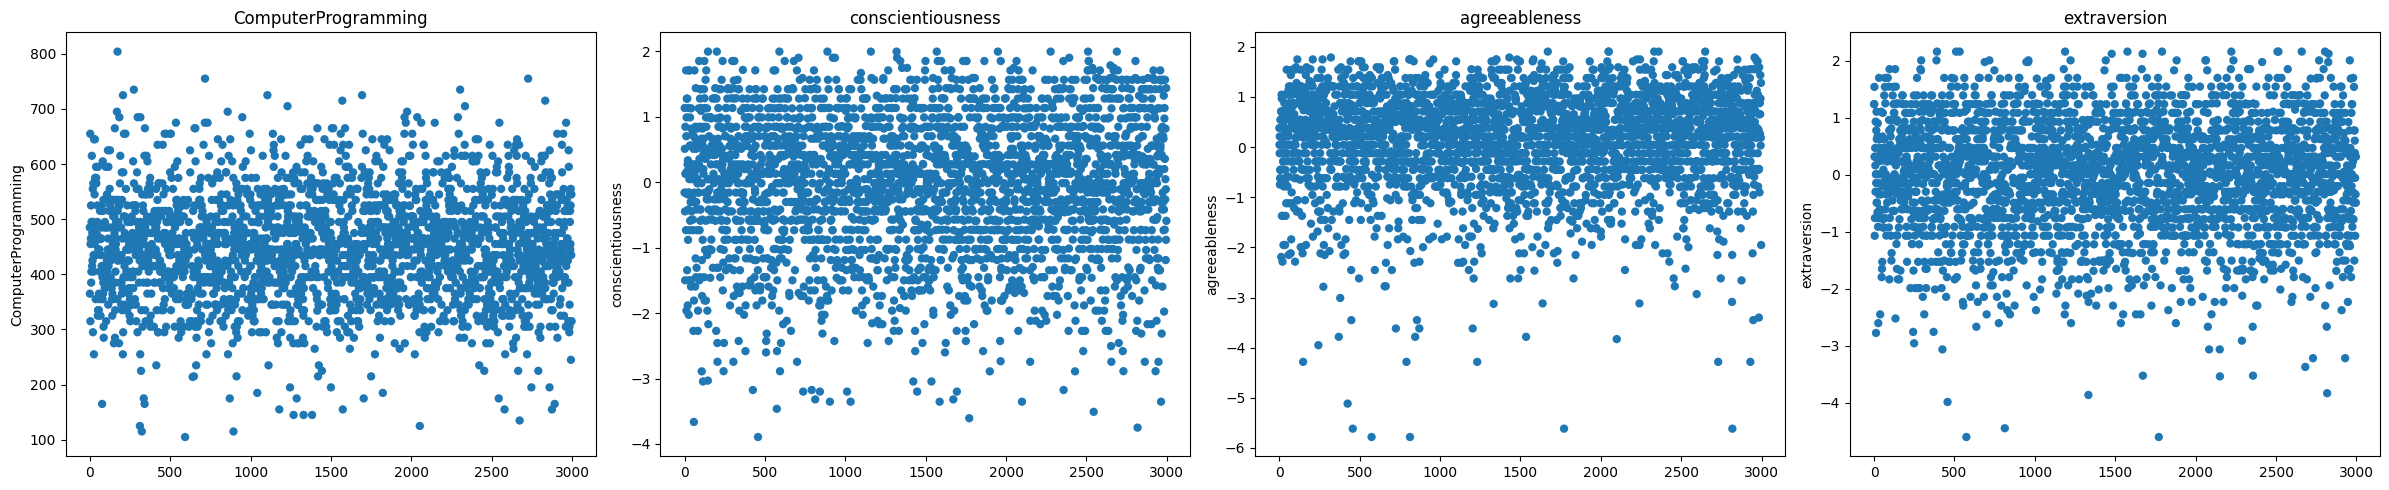

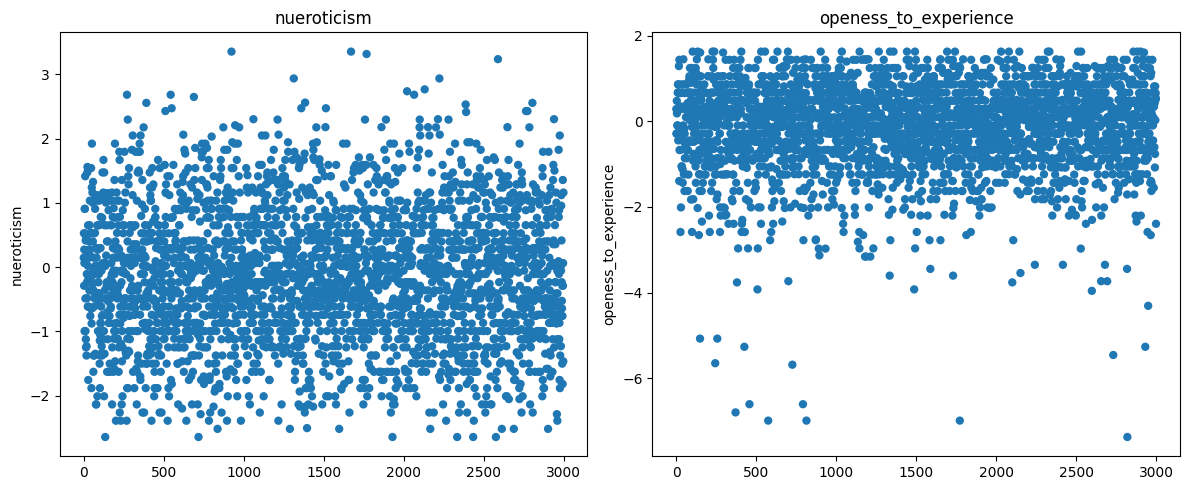

In [83]:
df2_num = df2.select_dtypes(include=['float64', 'int64'])
df2_dist = df2_num.drop("Salary", axis=1)

for i in range(0, len(df2_dist.columns), 4):
    cols_to_plot = df2_dist.columns[i:i+4]
    fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(6 * len(cols_to_plot), 5))

    # Make sure axes is always iterable
    if len(cols_to_plot) == 1:
        axes = [axes]

    for j, col in enumerate(cols_to_plot):
        sns.scatterplot(x=df2_dist.index, y=df2_dist[col], ax=axes[j], edgecolor="None")
        axes[j].set_title(col, fontsize=12)
        axes[j].set_xlabel(None)

    plt.tight_layout()
    plt.show()


# [2] Exploratory Data Analysis

## Looking for Correlations 

In [84]:
df2_num = df2.select_dtypes(include = ['float64', 'int64'])
df2_num_corr = df2_num.corr()['Salary'][:-1] # -1 means that the latest row is Salary
#menghitung koefisien korelasi pearson dari setiap feature numerik ke target 'SalePrice'
top_features = df2_num_corr.sort_values(ascending=False)
top_features

Quant                    0.238025
ComputerProgramming      0.201491
Logical                  0.192844
Domain                   0.184818
10percentage             0.180528
English                  0.178810
12percentage             0.171857
collegeGPA               0.149643
agreeableness            0.074807
openess_to_experience    0.000987
extraversion            -0.004129
conscientiousness       -0.046078
nueroticism             -0.069793
CollegeTier             -0.175449
Name: Salary, dtype: float64

It is seen that Quant, ComputerProgramming, and Logical have the highest correlation with Salary. We can also see features' correlations to salary in a bar plot.

<Axes: title={'center': 'Correlations of Every Feature to Salary'}>

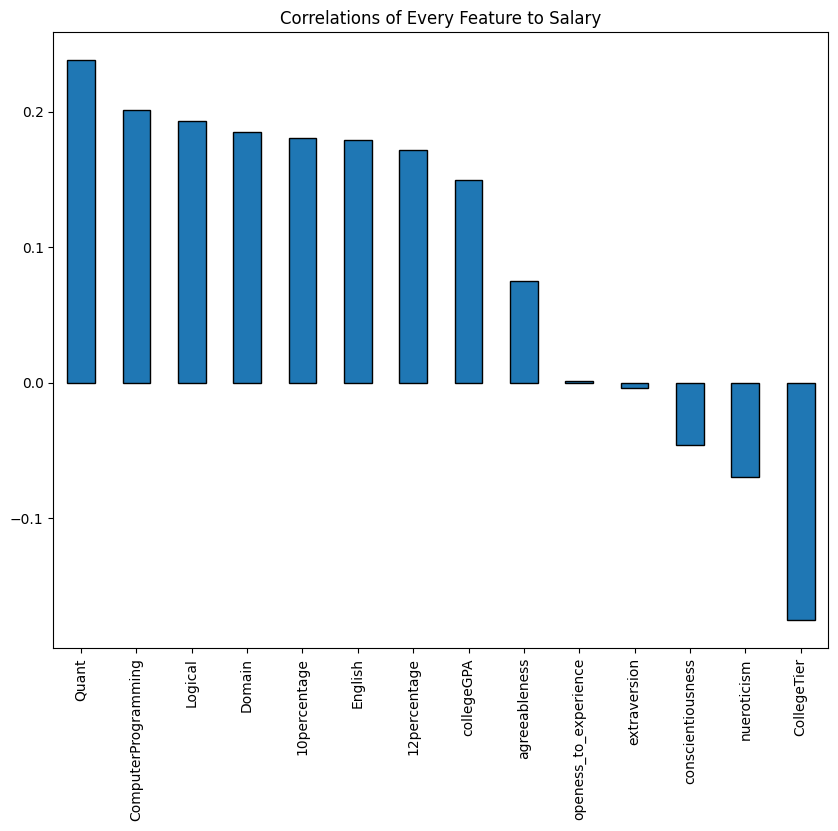

In [85]:
top_features.plot(kind='bar',figsize=(10,8), title='Correlations of Every Feature to Salary', color='tab:blue', edgecolor='black')

We can also create pairplot and heatmap to better understand the target and feature relationship visually.

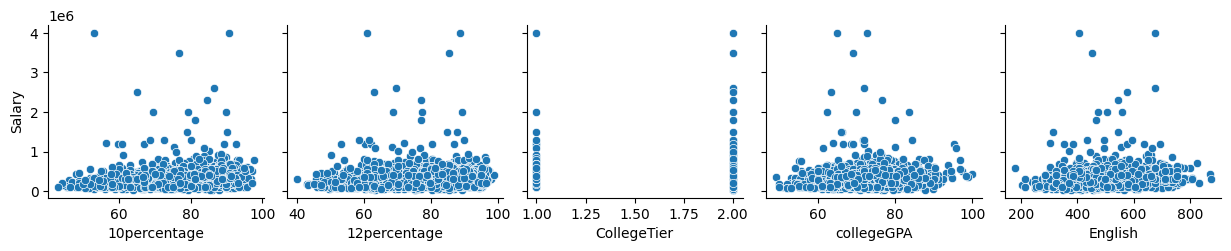

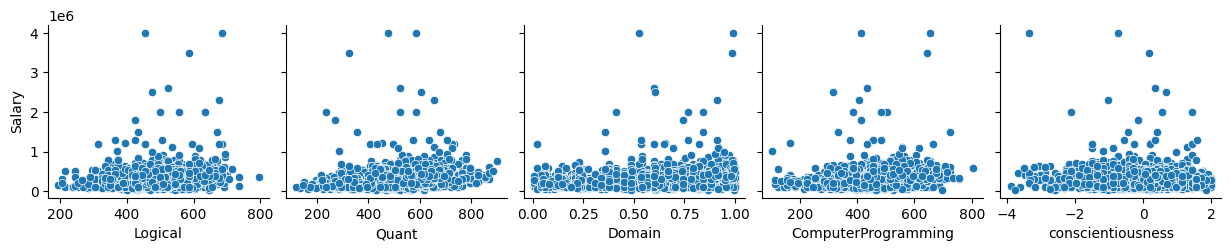

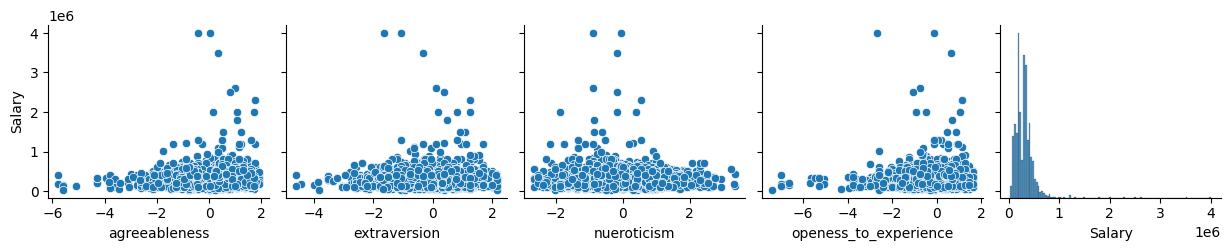

In [86]:
sns.set_palette('tab10')
for i in range(0, len(df2_num.columns), 5):
    sns.pairplot(data=df2_num,
                x_vars=df2_num.columns[i:i+5],
                y_vars=['Salary'])

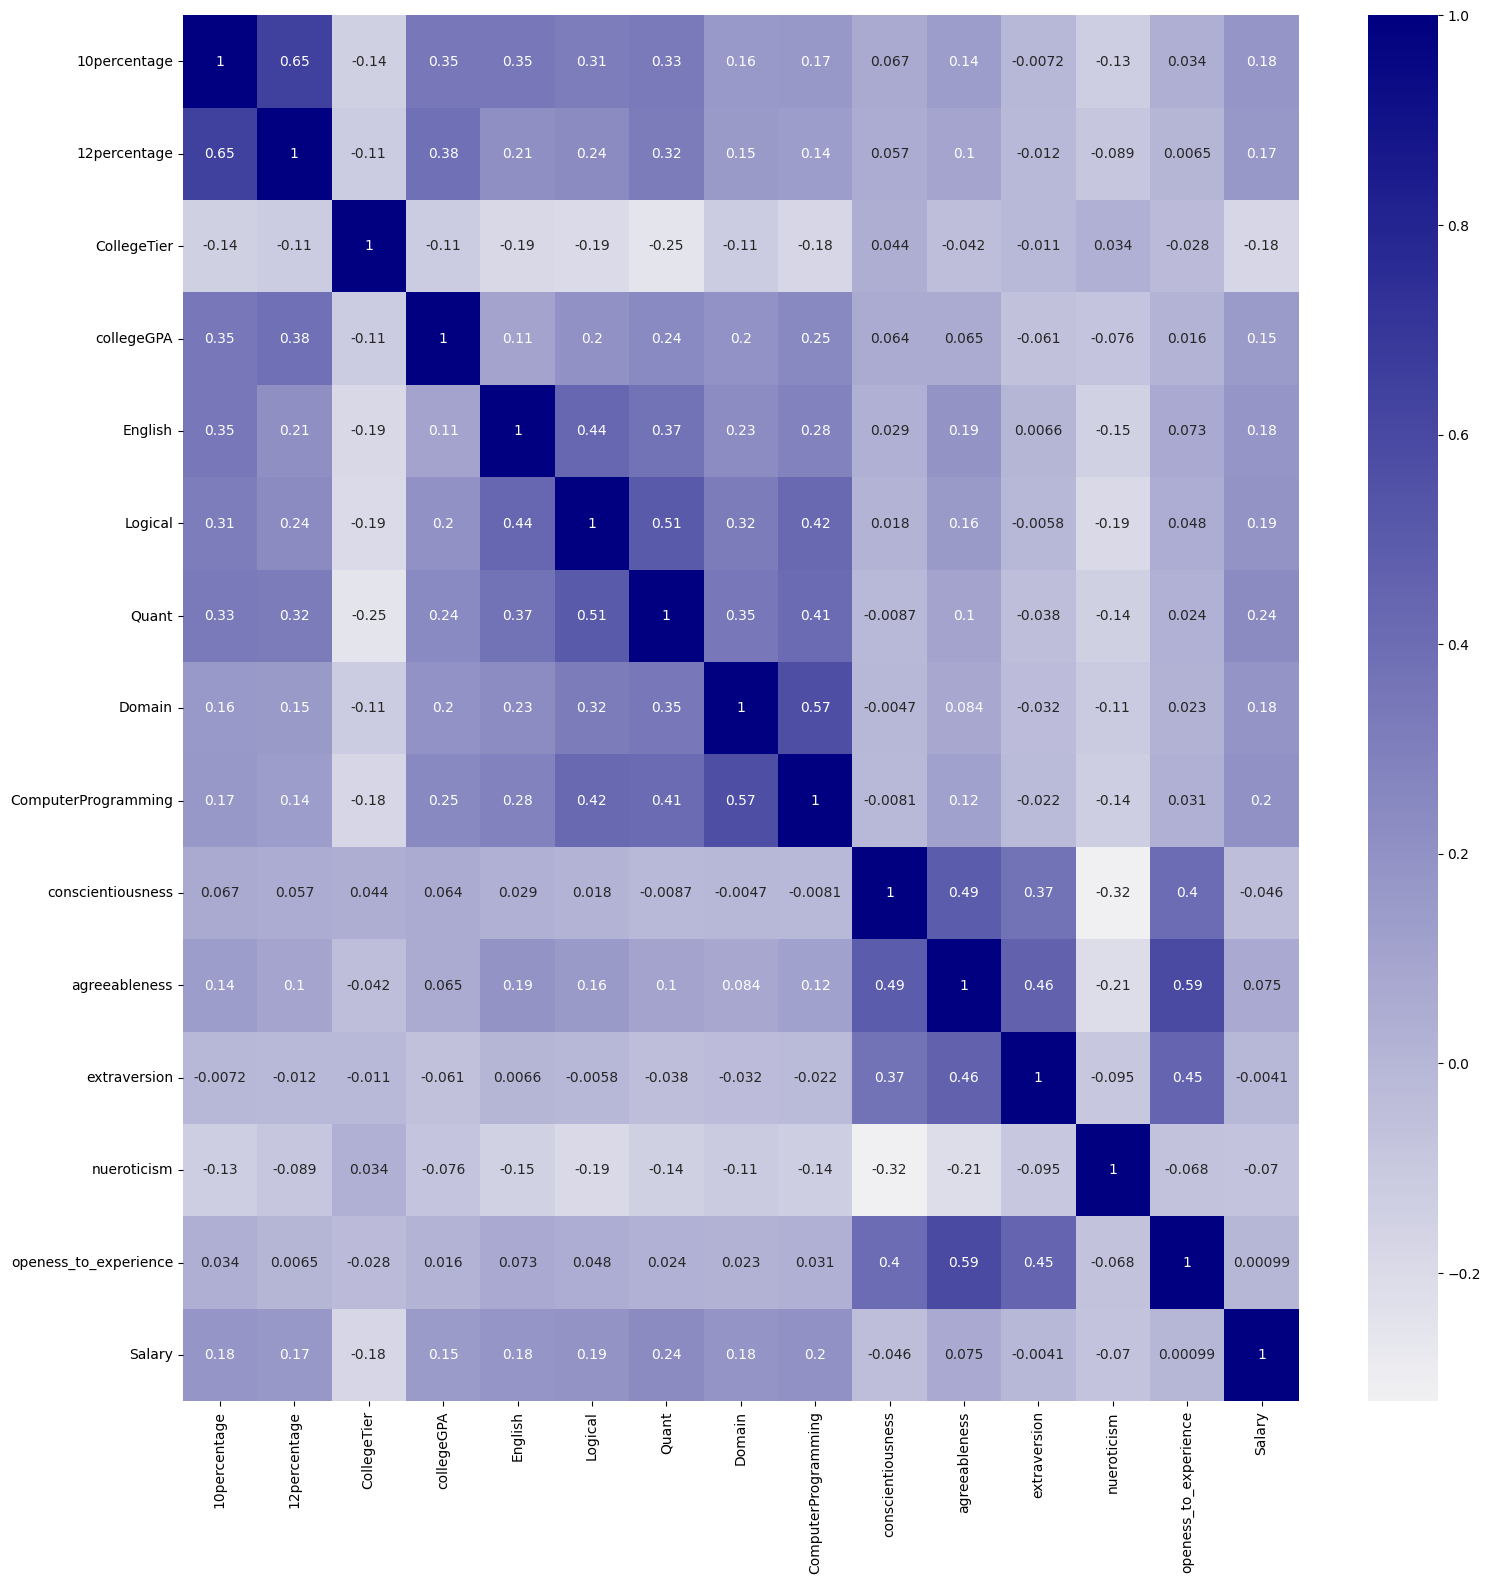

In [87]:
my_cmap = sns.light_palette("Navy", as_cmap=True)
plt.figure(figsize=(18,18))
sns.heatmap(df2_num.corr(),annot=True,cmap=my_cmap)

plt.show()

## Skew Variables 

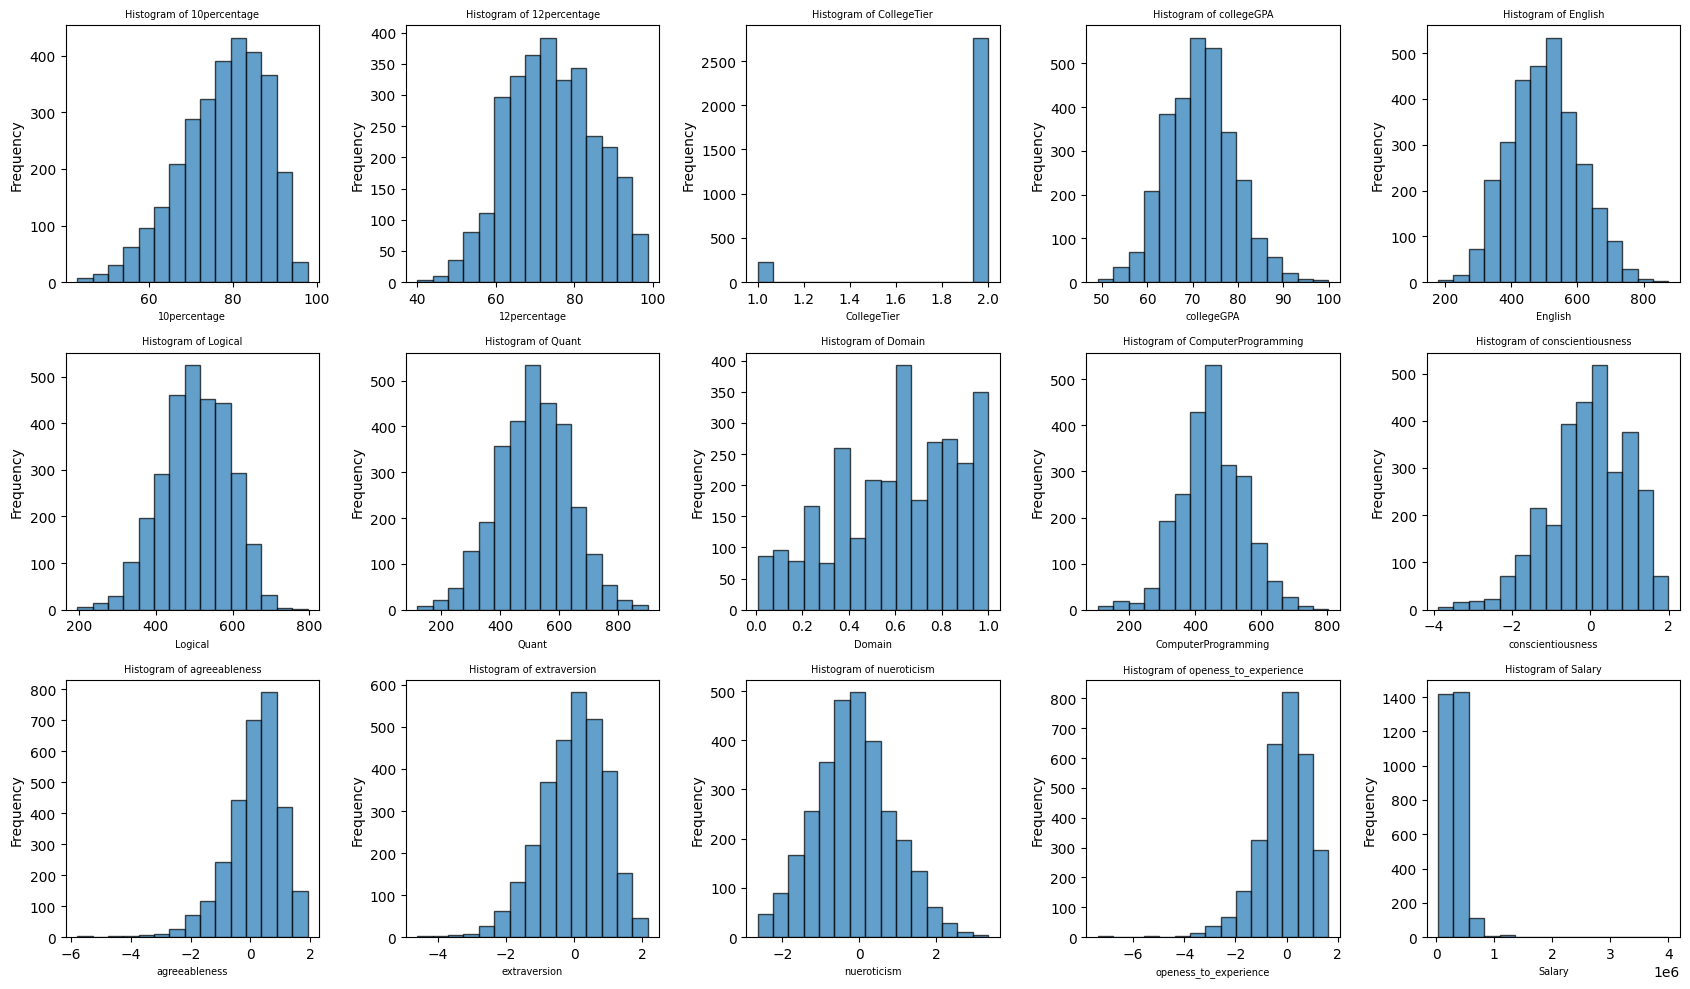

In [88]:
# Number of histograms to display
num_histograms = 15

# Create a 4x4 grid of subplots to accommodate 16 histograms
num_rows = 3
num_cols = 5

# Create a figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(17, 10))

# Flatten the axes array to iterate through subplots easily
axes_flat = axes.flatten()

# Iterate through the DataFrame columns and plot histograms with distinct colors
for i, (column, ax) in enumerate(zip(df2_num.columns, axes_flat)):
    df2_num[column].plot.hist(ax=ax, bins=15, alpha=0.7, color='tab:blue', edgecolor='black')
    ax.set_title(f'Histogram of {column}', fontsize = 7)
    ax.set_xlabel(column, fontsize = 7)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [89]:
skew_limit = 0.75
skew_vals = df2_num.skew()

In [90]:
skew_vals

10percentage            -0.576969
12percentage            -0.024342
CollegeTier             -3.230361
collegeGPA               0.176865
English                  0.188906
Logical                 -0.211478
Quant                   -0.040874
Domain                  -0.363457
ComputerProgramming     -0.028174
conscientiousness       -0.516684
agreeableness           -1.263306
extraversion            -0.522413
nueroticism              0.169693
openess_to_experience   -1.547854
Salary                   6.980897
dtype: float64

In [91]:
skew_cols = skew_vals[abs(skew_vals)>skew_limit].sort_values(ascending=False)
#a = abs(skew_cols)
skew_cols

Salary                   6.980897
agreeableness           -1.263306
openess_to_experience   -1.547854
CollegeTier             -3.230361
dtype: float64

Using a skewness cutoff of ±0.75, we identified that the variables Salary, agreeableness, openess_to_experience, and CollegeTier exhibit significant skewness. Therefore, these features will be transformed to reduce skewness and achieve a more normalized distribution. Except for CollegeTier, because the values are actually categorical.

Based on the skewness analysis using a cutoff threshold of ±0.75, the variable Salary was found to be highly right-skewed (skewness = 6.9). To reduce skewness and approximate a normal distribution, a transformation is applied. This step helps stabilize variance and improve the performance of machine learning models that assume normally distributed target values. To identify the most suitable transformation, we compare multiple transformation methods both numerically (via skewness) and visually (through distribution plots).

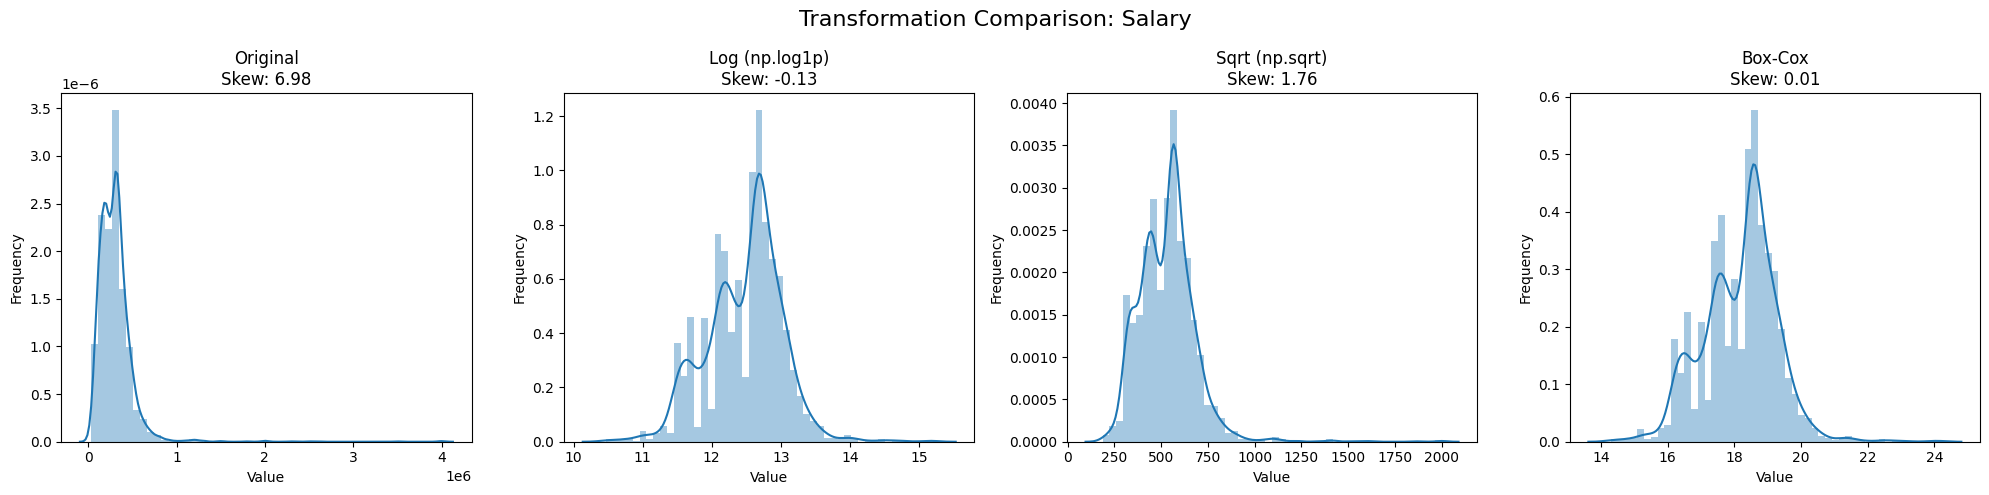

In [102]:
field = "Salary"

# Drop NaN and ensure positive
data = df2[field].dropna()
data_positive = data[data > 0]  # Required for Box–Cox

# Transformations
log_transformed = np.log1p(data)
sqrt_transformed = np.sqrt(data)
boxcox_transformed, _ = boxcox(data_positive)

# Skewness
skews = {
    "Original": skew(data),
    "Log (np.log1p)": skew(log_transformed),
    "Sqrt (np.sqrt)": skew(sqrt_transformed),
    "Box-Cox": skew(boxcox_transformed),
}

# Plot comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["Original", "Log (np.log1p)", "Sqrt (np.sqrt)", "Box-Cox"]
datasets = [data, log_transformed, sqrt_transformed, boxcox_transformed]

for ax, (title, transformed) in zip(axes, zip(titles, datasets)):
    sns.distplot(transformed, ax=ax, kde=True, color="tab:blue")
    ax.set_title(f"{title}\nSkew: {skews[title]:.2f}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle(f"Transformation Comparison: {field}", fontsize=16)
plt.tight_layout()
plt.show()

After testing several transformation techniques (log, sqrt, Box–Cox) on the Salary variable, the Box–Cox transformation produced the most normally distributed result, with the skewness reduced from 6.9 to 0.01. This indicates a substantial improvement in symmetry and distribution balance. Therefore, the Box–Cox transformation was selected as the final approach to normalize the target variable Salary, as it preserves data variation while effectively minimizing skewness.

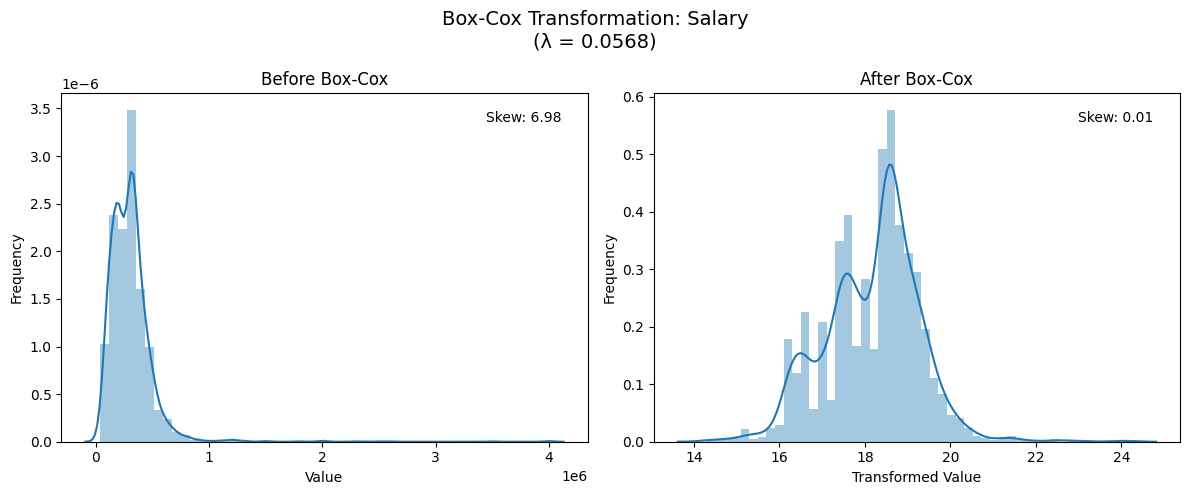

In [108]:
field = "Salary"

# Drop missing values
salary_data = df2[field].dropna()

# Apply Box-Cox transformation (returns transformed values and lambda)
salary_boxcox, fitted_lambda = boxcox(salary_data)

# Calculate skewness
skew_before = skew(salary_data)
skew_after = skew(salary_boxcox)

# Create subplots
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(12, 5))

# Plot before transformation
sns.distplot(salary_data, kde=True, ax=ax_before, color='tab:blue')
ax_before.set(title='Before Box-Cox', ylabel='Frequency', xlabel='Value')
ax_before.text(0.95, 0.95, f"Skew: {skew_before:.2f}",
               transform=ax_before.transAxes, ha='right', va='top',
               bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Plot after transformation
sns.distplot(salary_boxcox, kde=True, ax=ax_after, color='tab:blue')
ax_after.set(title='After Box-Cox', ylabel='Frequency', xlabel='Transformed Value')
ax_after.text(0.95, 0.95, f"Skew: {skew_after:.2f}",
              transform=ax_after.transAxes, ha='right', va='top',
              bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Add a super title
fig.suptitle(f'Box-Cox Transformation: {field}\n(λ = {fitted_lambda:.4f})', fontsize=14)

plt.tight_layout()
plt.show()


Since Salary is the target variable, we will apply the transformation to the column itself directly.

In [ ]:
# Apply the log transformation to Salary

df2["Salary"] = np.log1p(df2["Salary"])

Now, for agreeableness variable we will see first visually and numerically which transformation will fit the best.

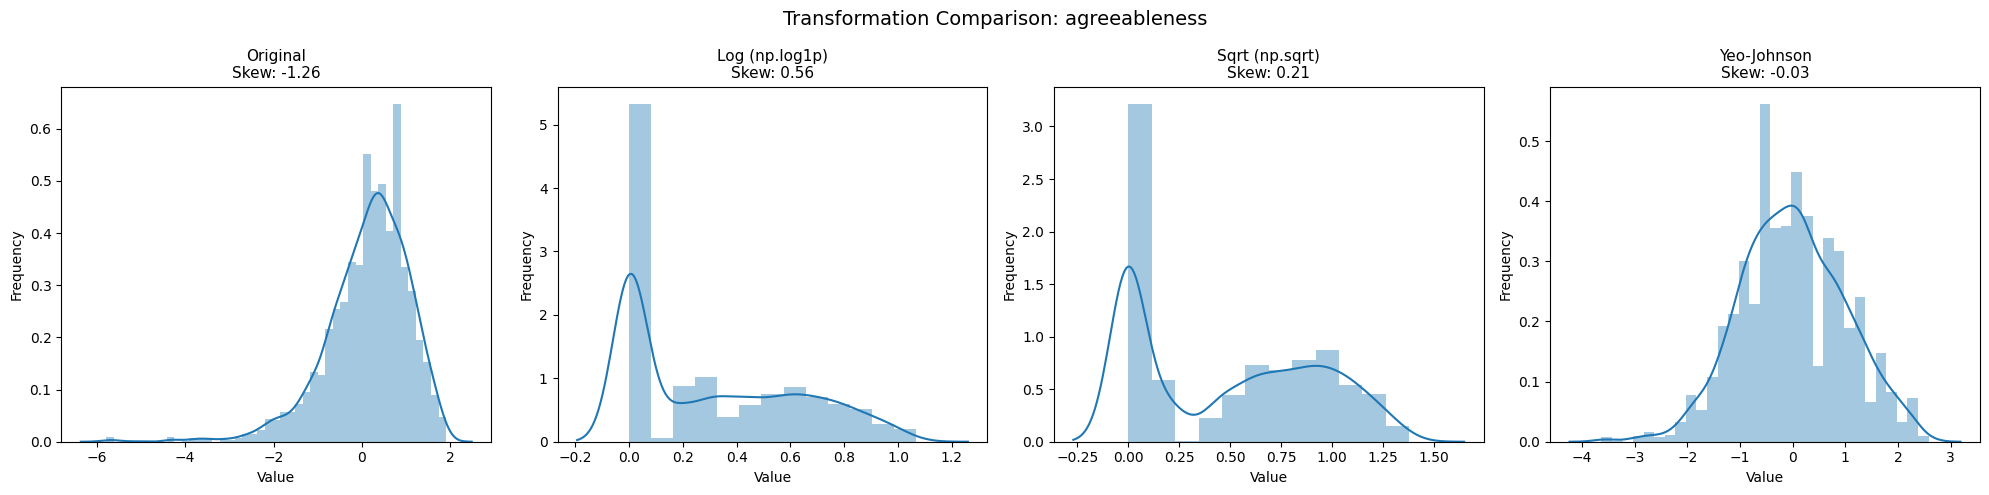

In [60]:
field = "agreeableness"

# Prepare transformations safely
original = df2[field].dropna()
log_transformed = np.log1p(original.clip(lower=0))           # handles zeros
sqrt_transformed = np.sqrt(original.clip(lower=0))           # handles negatives
yeojohnson_transformed = PowerTransformer(method='yeo-johnson').fit_transform(original.values.reshape(-1, 1)).flatten()

# Store results in a dict for easy looping
transforms = {
    "Original": original,
    "Log (np.log1p)": log_transformed,
    "Sqrt (np.sqrt)": sqrt_transformed,
    "Yeo-Johnson": yeojohnson_transformed
}

# Create 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, data) in zip(axes, transforms.items()):
    sns.distplot(data, ax=ax, kde=True, color='tab:blue')
    ax.set_title(f"{name}\nSkew: {skew(data):.2f}", fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

fig.suptitle(f"Transformation Comparison: {field}", fontsize=14)
plt.tight_layout()
plt.show()


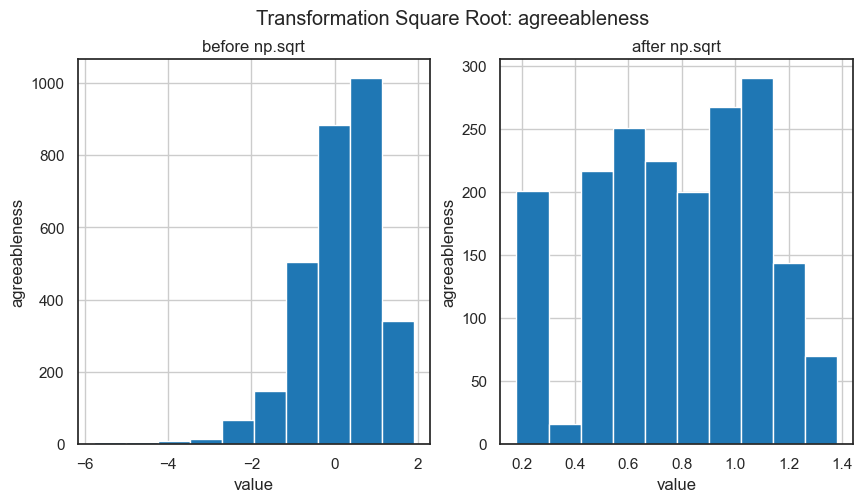

In [103]:
#Choose a field
field1 = "agreeableness"

#Create two "subplots" and ad "figure" using matplotlib
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(10,5))
#plt.subplots is going to allow you to graph 2 axis in 1 figure

#Create a histogram on the "ax_before" subplot
df2[field1].hist(ax=ax_before, color='tab:blue', edgecolor='white')
#We have a positive skew (right-skewed), consistent with skew values that we have in the cell above

#Apply a log transformation (numpy syntax) to this column
df2[field1].apply(np.sqrt).hist(ax=ax_after, color='tab:blue', edgecolor='white')
#We see that we have a much more normally distributed dataset

#Formatting of titles etc. for each subplot
ax_before.set(title='before np.sqrt', ylabel='agreeableness', xlabel='value')
ax_after.set(title='after np.sqrt', ylabel='agreeableness', xlabel='value')
fig.suptitle('Transformation Square Root: agreeableness'); #suptitle is super title

Skewness: -1.263306


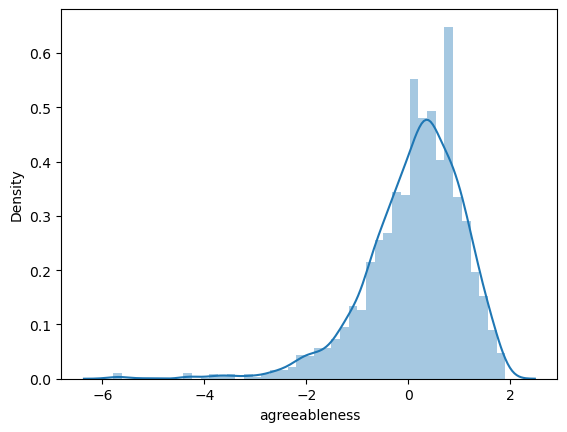

In [40]:
# Enter your code and run the cell
agreeableness_untransformed = sns.distplot(df2['agreeableness'])
print("Skewness: %f" % df2['agreeableness'].skew())

Skewness: -0.266390


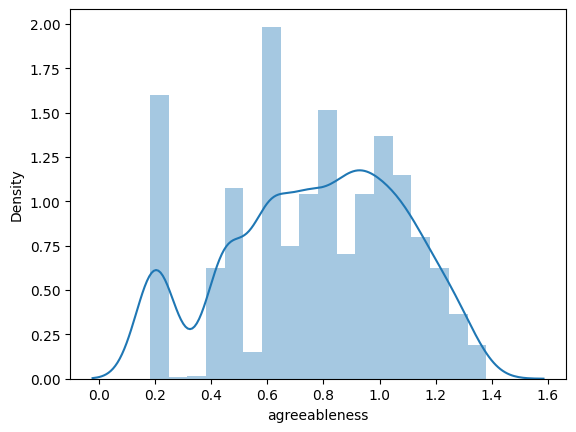

In [59]:
sqrt_transformed1 = np.sqrt(df2['agreeableness'])
agreeableness_transformed1 = sns.distplot(sqrt_transformed1)
print("Skewness: %f" % (sqrt_transformed1).skew())

## Exploratory Data Analysis (more)

In [42]:
df2.columns

Index(['Gender', '10percentage', '12percentage', 'CollegeTier', 'Degree',
       'Specialization', 'collegeGPA', 'English', 'Logical', 'Quant', 'Domain',
       'ComputerProgramming', 'ElectronicsAndSemicon', 'ComputerScience',
       'MechanicalEngg', 'ElectricalEngg', 'TelecomEngg', 'CivilEngg',
       'conscientiousness', 'agreeableness', 'extraversion', 'nueroticism',
       'openess_to_experience', 'Salary'],
      dtype='object')

In [43]:
dist_Gender = df2['Gender'].value_counts(ascending=False)
dist_Gender

m    2274
f     715
Name: Gender, dtype: int64

In [44]:
palette_Spectral = sns.color_palette('Spectral', 10)
palette_inferno = sns.color_palette('inferno', 10)
palette_icefire = sns.color_palette('icefire', 10)
palette_viridis = sns.color_palette('viridis', 10)
palette_red = sns.color_palette('RdYlGn', 10)
palette_coolwarm = sns.color_palette('coolwarm', 10)

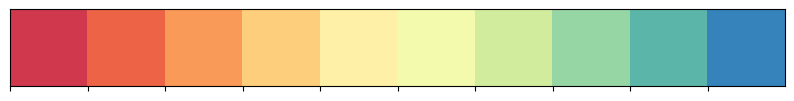

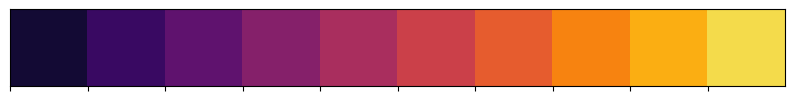

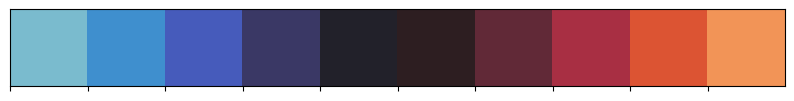

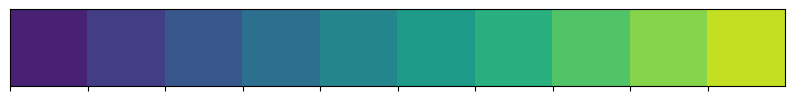

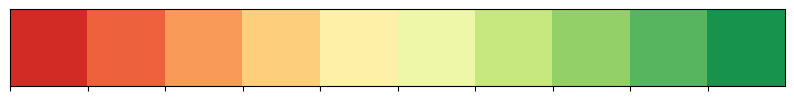

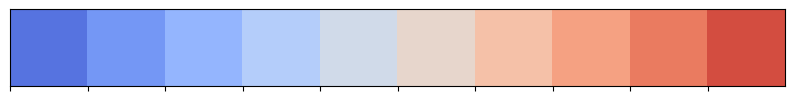

In [45]:
sns.palplot(palette_Spectral)
sns.palplot(palette_inferno)
sns.palplot(palette_icefire)
sns.palplot(palette_viridis)
sns.palplot(palette_red)
sns.palplot(palette_coolwarm)

In [113]:
#palette_Spectral = sns.color_palette("Spectral", 10)
#palette1 = sns.color_palette([palette_Spectral[0], palette_Spectral[1], palette_Spectral[3]])
#sns.palplot(palette_Spectral)

In [112]:
#sns.palplot(palette1)

In [48]:
cmap_Gender = sns.color_palette([palette_inferno[0], palette_inferno[5]], as_cmap=True)

<Axes: title={'center': 'Distribution of Gender'}>

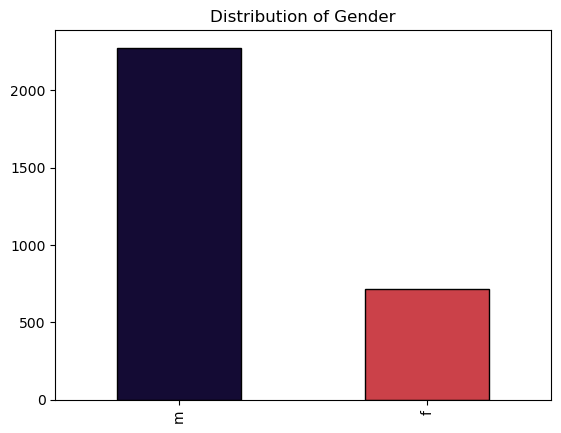

In [49]:
dist_Gender.plot(kind='bar', title='Distribution of Gender', color=cmap_Gender, edgecolor='black')

In [50]:
dist_CollegeTier = df2['CollegeTier'].value_counts(ascending=False)
dist_CollegeTier

2    2765
1     224
Name: CollegeTier, dtype: int64

In [114]:
palette_coolwarm = sns.color_palette("coolwarm", 300)
#palette2 = sns.color_palette([palette_coolwarm[0], palette_coolwarm[1], palette_viridis[3]])
#sns.palplot(palette_coolwarm)

In [115]:
cmap_CG = sns.color_palette([palette_coolwarm[299], palette_coolwarm[0]], as_cmap=True)

<Axes: title={'center': 'Distribution of CollegeTier'}>

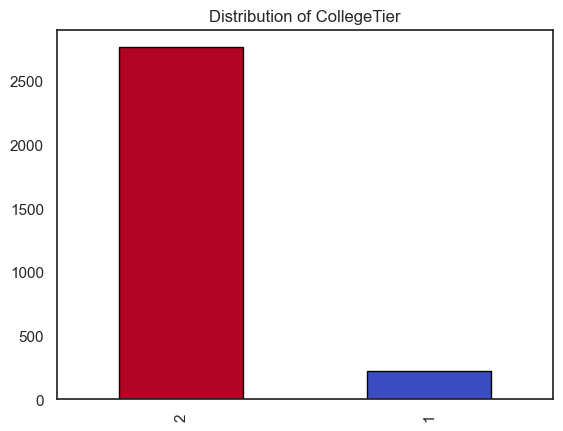

In [116]:
#color_palette_CG = sns.color_palette("coolwarm")
dist_CollegeTier.plot(kind='bar', title='Distribution of CollegeTier', color=cmap_CG , edgecolor='black')

In [54]:
dist_degree = df2['Degree'].value_counts(ascending=False)
dist_degree

B.Tech/B.E.      2750
MCA               200
M.Tech./M.E.       38
M.Sc. (Tech.)       1
Name: Degree, dtype: int64

In [55]:
cmap_Degree = sns.color_palette([palette_icefire[5], palette_icefire[3], palette_Spectral[9], palette_Spectral[5]], as_cmap=True)

<Axes: title={'center': 'Distribution of Degree'}>

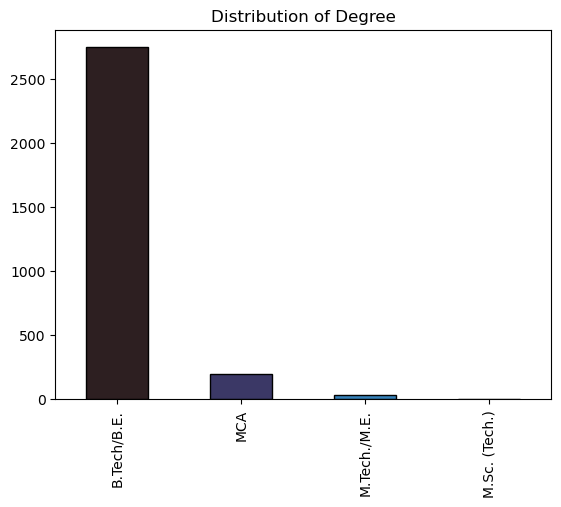

In [59]:
#color_palette_Degree = sns.color_palette('inferno')
dist_degree.plot(kind='bar', title='Distribution of Degree', color=cmap_Degree, edgecolor='black')

In [60]:
dist_spec = df2['Specialization'].value_counts(ascending=False)
dist_spec

electronics and communication engineering      670
computer science & engineering                 556
information technology                         503
computer engineering                           414
computer application                           201
mechanical engineering                         152
electronics and electrical engineering         148
electronics & telecommunications                89
Others                                          76
electrical engineering                          63
electronics & instrumentation eng               24
electronics and instrumentation engineering     18
instrumentation and control engineering         18
information science engineering                 18
civil engineering                               15
electronics engineering                         12
biotechnology                                   12
Name: Specialization, dtype: int64

<Axes: title={'center': 'Distribution of Specialization'}>

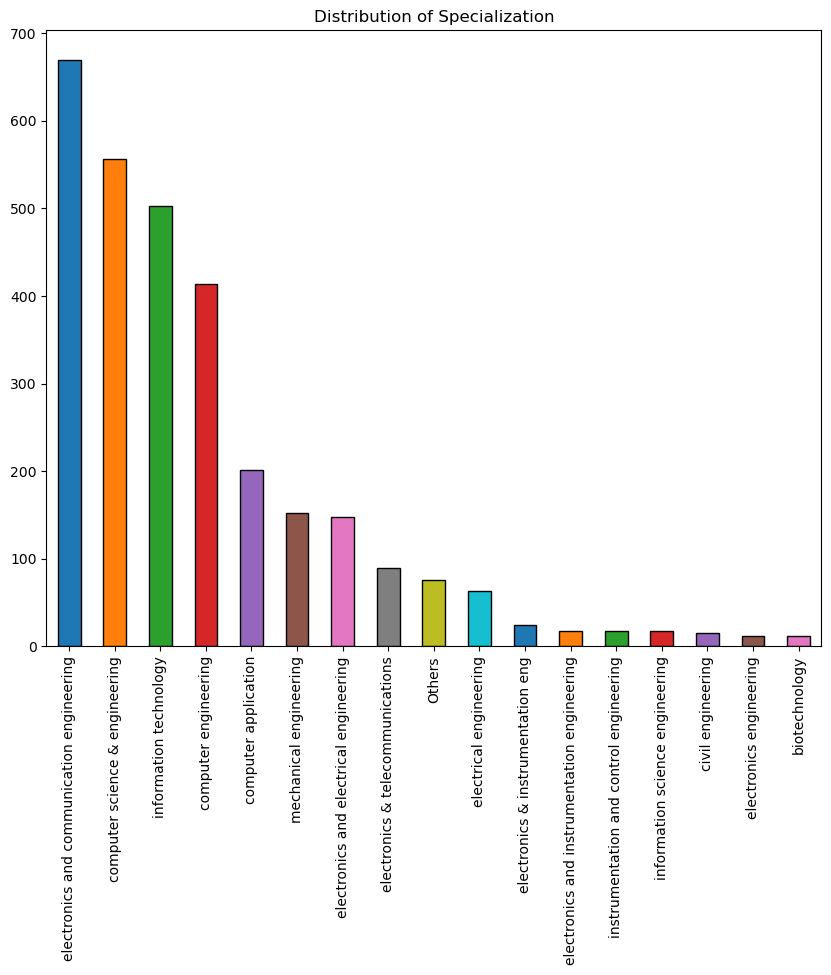

In [61]:
color_palette_Spec = sns.color_palette('tab10')
dist_spec.plot(kind='bar',figsize=(10,8), title='Distribution of Specialization', color=color_palette_Spec, edgecolor='black')

In [62]:
df3 = df2[['Gender', 'Degree', 'collegeGPA', 'Salary', 'Specialization', 'CollegeTier']].copy()
df3.head()

,Gender,Degree,collegeGPA,Salary,Specialization,CollegeTier
0,f,B.Tech/B.E.,73.82,445000,instrumentation and control engineering,1
1,m,B.Tech/B.E.,65.00,110000,computer science & engineering,2
2,m,B.Tech/B.E.,61.94,255000,electronics & telecommunications,2
3,m,B.Tech/B.E.,80.40,420000,computer science & engineering,1
4,f,B.Tech/B.E.,64.30,200000,biotechnology,2


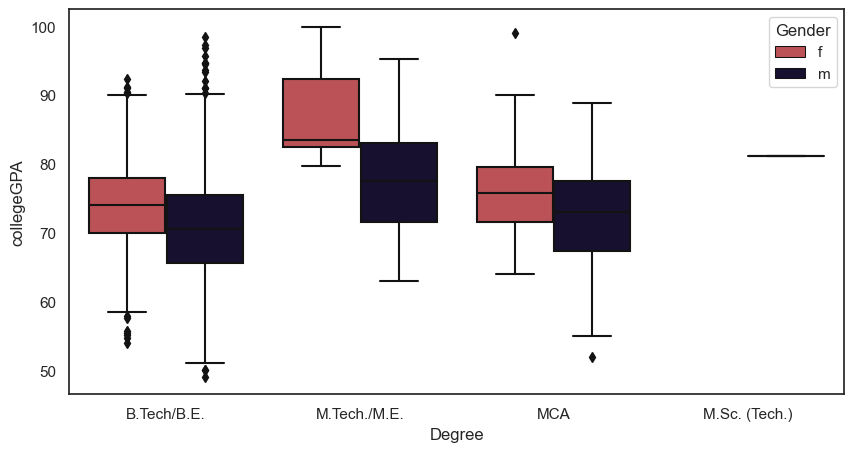

In [63]:
sns.set_style('white')
sns.set_context('notebook')
#sns.set_palette('cmap_Gender')
#cmap_Gender1 = sns.color_palette([palette_tab10[0], palette_tab10[2], palette_tab10[1]], as_cmap=True)
cmap_Gender1 = sns.color_palette([palette_inferno[5], palette_inferno[0]], as_cmap=True)
sns.set_palette(sns.color_palette(cmap_Gender1))

f = plt.figure(figsize=(10,5))
sns.boxplot(x='Degree', y='collegeGPA', 
            hue='Gender', data=df2);

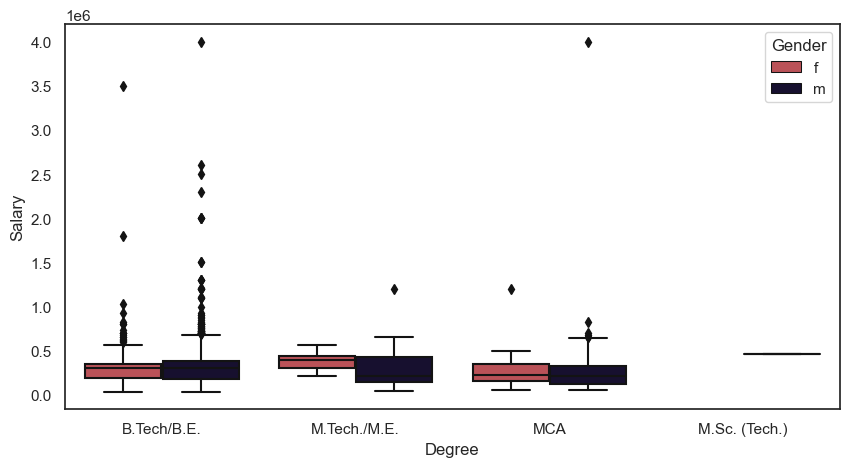

In [64]:
sns.set_style('white')
sns.set_context('notebook')
#sns.set_palette('Spectral')
sns.set_palette(sns.color_palette(cmap_Gender1))

f = plt.figure(figsize=(10,5))
sns.boxplot(x='Degree', y='Salary', 
            hue='Gender', data=df2);

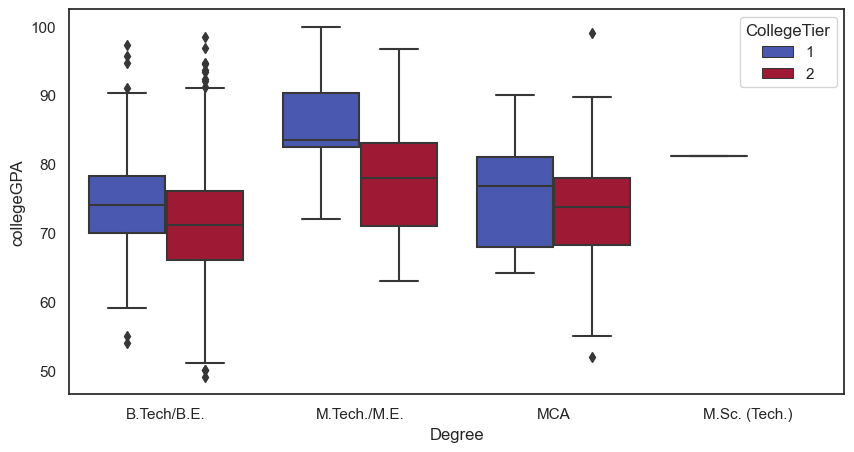

In [65]:
sns.set_style('white')
sns.set_context('notebook')
#sns.set_palette('tab10')
#cmap_CG1 = sns.color_palette([palette_coolwarm[0], palette_coolwarm[9], palette_coolwarm[1]], as_cmap=True)
cmap_CG1 = sns.color_palette([palette_coolwarm[0], palette_coolwarm[299]], as_cmap=True)
sns.set_palette(sns.color_palette(cmap_CG1))

f = plt.figure(figsize=(10,5))
sns.boxplot(x='Degree', y='collegeGPA', 
            hue='CollegeTier', data=df2);

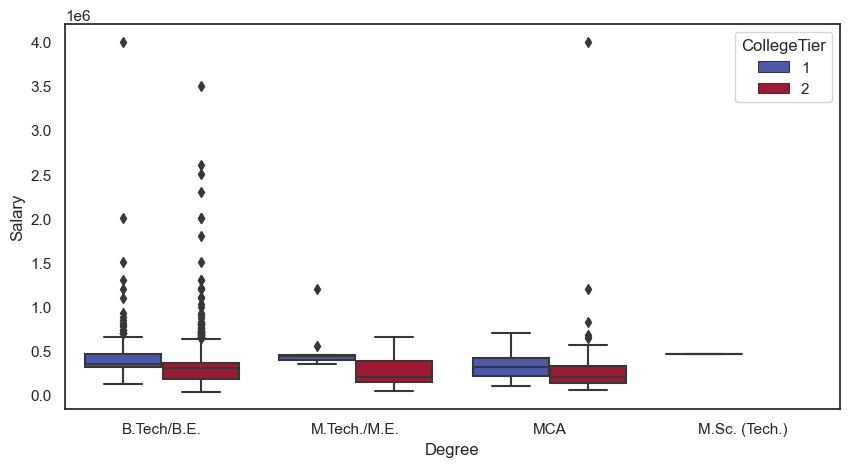

In [66]:
sns.set_style('white')
sns.set_context('notebook')
#sns.set_palette('tab10')
sns.set_palette(sns.color_palette(cmap_CG1))

f = plt.figure(figsize=(10,5))
sns.boxplot(x='Degree', y='Salary', 
            hue='CollegeTier', data=df2);

<Axes: xlabel='collegeGPA', ylabel='Salary'>

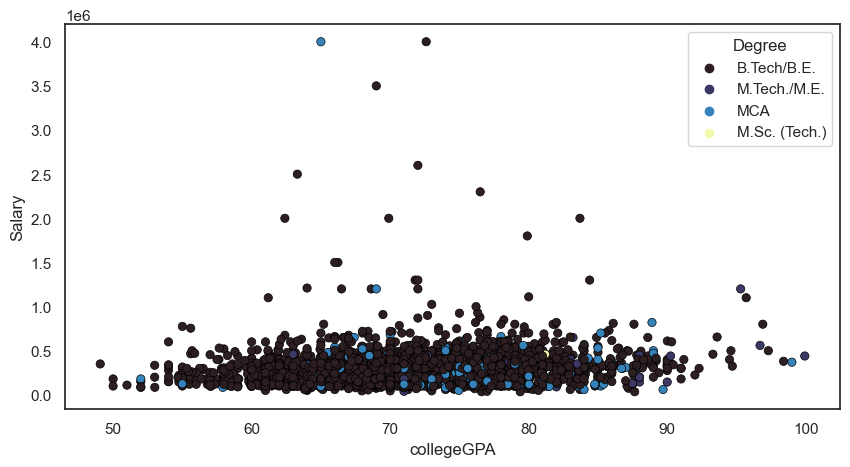

In [67]:
plt.figure(figsize = (10,5))
sns.set_palette(sns.color_palette(cmap_Degree))
sns.scatterplot(data=df3, x=df3.collegeGPA, y=df3.Salary, hue = df3.Degree, edgecolor='black')

<Axes: xlabel='collegeGPA', ylabel='Salary'>

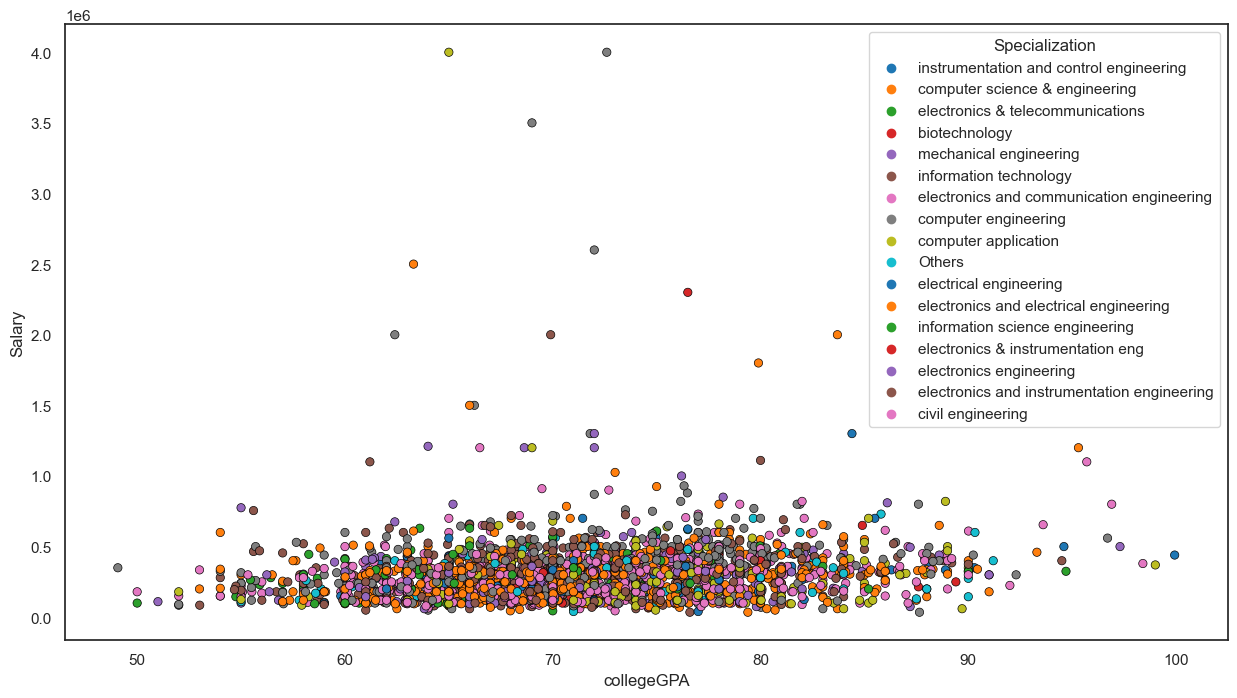

In [68]:
plt.figure(figsize = (15,8))
sns.scatterplot(data=df3, x=df3.collegeGPA, y=df3.Salary, hue = df3.Specialization, palette = 'tab10', edgecolor='black')

<Axes: xlabel='collegeGPA', ylabel='Salary'>

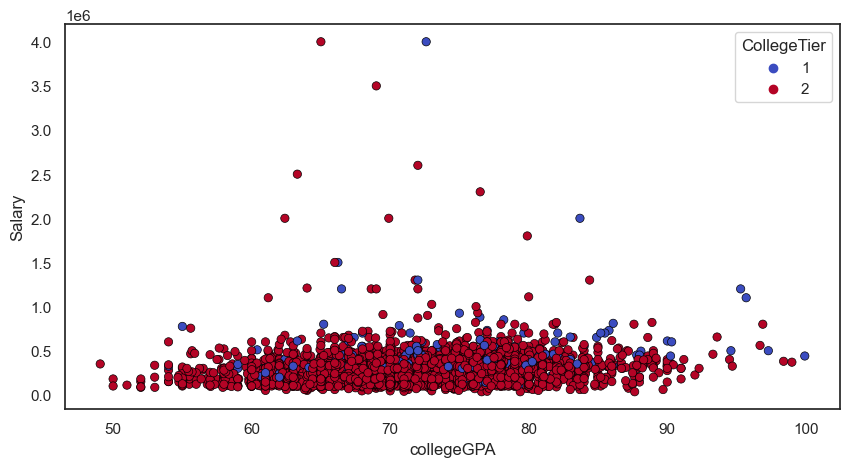

In [69]:
plt.figure(figsize = (10,5))
#sns.set_palette(sns.color_palette(cmap_Degree))
sns.scatterplot(data=df3, x=df3.collegeGPA, y=df3.Salary, hue = df3.CollegeTier, palette='coolwarm', edgecolor='black')

<Axes: xlabel='collegeGPA', ylabel='Salary'>

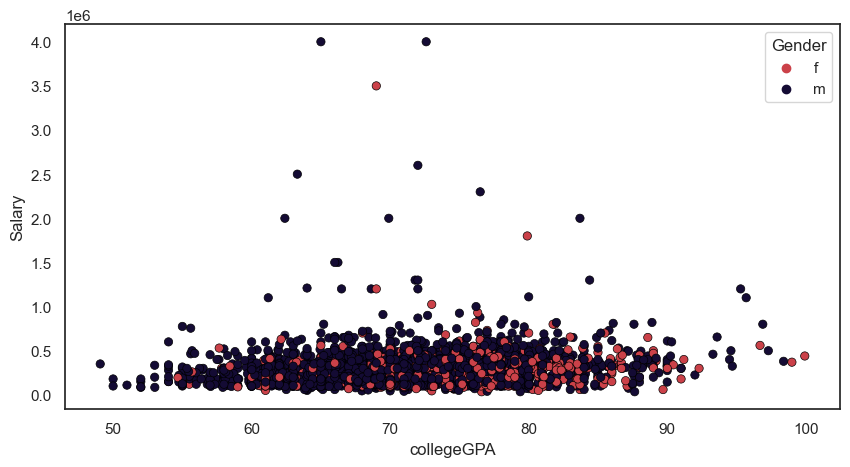

In [70]:
plt.figure(figsize = (10,5))
sns.set_palette(sns.color_palette(cmap_Gender1))
sns.scatterplot(data=df3, x=df3.collegeGPA, y=df3.Salary, hue = df3.Gender, edgecolor='black')

<Axes: xlabel='Salary', ylabel='Specialization'>

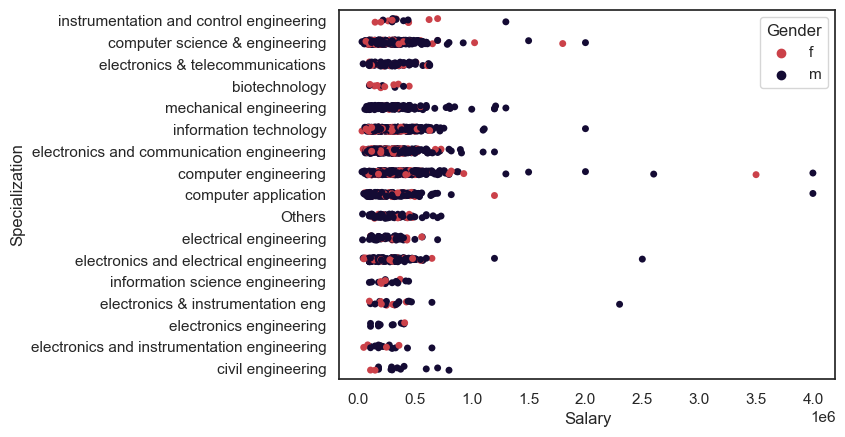

In [71]:
#sns.set_palette('tab10')
sns.set_palette(sns.color_palette(cmap_Gender1))
sns.stripplot(data=df3, x='Salary', y="Specialization", hue="Gender", edgecolor='black')

<Axes: xlabel='Salary', ylabel='Specialization'>

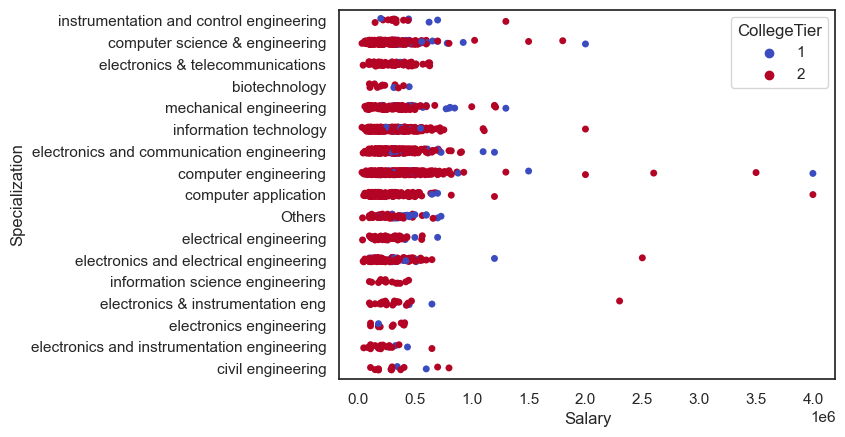

In [72]:
#sns.set_palette('Spectral')
sns.stripplot(data=df3, x='Salary', y="Specialization", hue="CollegeTier", palette='coolwarm', edgecolor='black')

<Axes: xlabel='collegeGPA', ylabel='Specialization'>

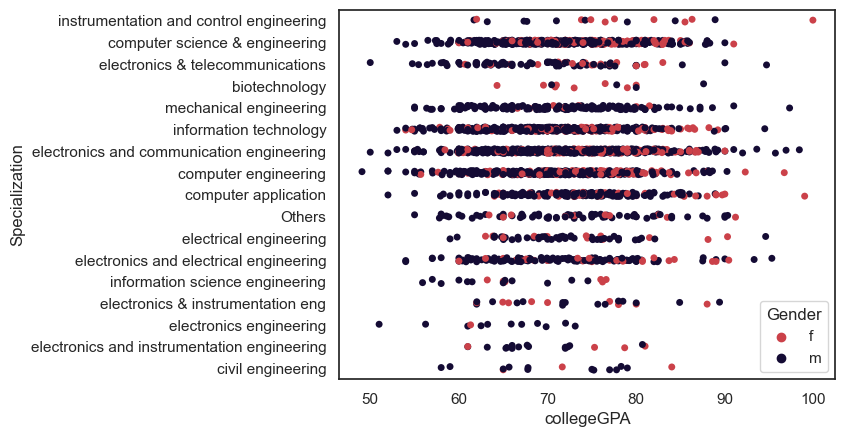

In [73]:
sns.set_palette(sns.color_palette(cmap_Gender1))
sns.stripplot(data=df3, x='collegeGPA', y="Specialization", hue="Gender")

<Axes: xlabel='collegeGPA', ylabel='Specialization'>

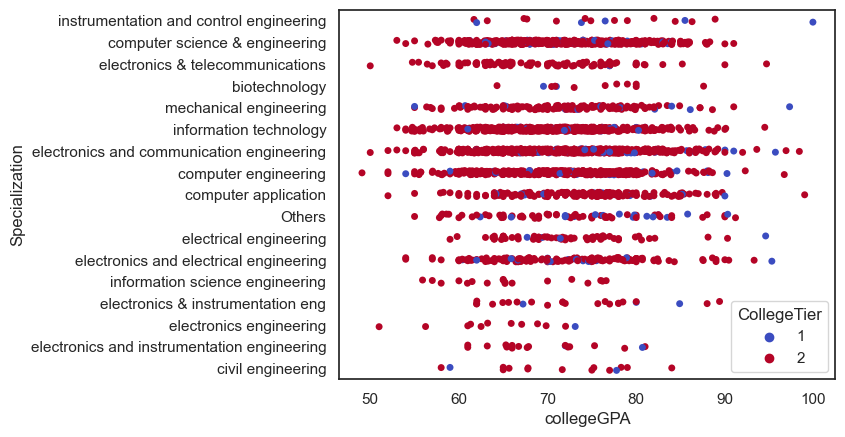

In [74]:
sns.stripplot(data=df3, x='collegeGPA', y="Specialization", hue="CollegeTier", palette='coolwarm')

# [3] Feature Engineering

## Data Preprocessing 

In [75]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2989 entries, 0 to 2997
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 2989 non-null   object 
 1   10percentage           2989 non-null   float64
 2   12percentage           2989 non-null   float64
 3   CollegeTier            2989 non-null   int64  
 4   Degree                 2989 non-null   object 
 5   Specialization         2989 non-null   object 
 6   collegeGPA             2989 non-null   float64
 7   English                2989 non-null   int64  
 8   Logical                2989 non-null   int64  
 9   Quant                  2989 non-null   int64  
 10  Domain                 2989 non-null   float64
 11  ComputerProgramming    2989 non-null   float64
 12  ElectronicsAndSemicon  2989 non-null   float64
 13  ComputerScience        2989 non-null   float64
 14  MechanicalEngg         2989 non-null   float64
 15  Elec

In [76]:
#We can see that Gender, Degree, and Specialization are 'object' variables, which aren't suitable for ML input.
#Hence, we need to process those variables

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df4 = df2.copy()
df4.Gender = le.fit_transform(df4.Gender)
df4.Degree = le.fit_transform(df4.Degree)
df4.Specialization = le.fit_transform(df4.Specialization)

In [77]:
df4.head()

,Gender,10percentage,12percentage,CollegeTier,Degree,Specialization,collegeGPA,English,Logical,Quant,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,0,87.80,84.00,1,0,15,73.82,650,665,810,...,401.174863,423.336066,349.879562,341.96,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,1,57.00,64.50,2,0,5,65.00,440,435,210,...,401.174863,423.336066,349.879562,341.96,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,1,77.33,85.17,2,0,8,61.94,485,475,505,...,401.174863,423.336066,260.000000,341.96,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,1,84.30,86.00,1,0,5,80.40,675,620,635,...,401.174863,423.336066,349.879562,341.96,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,0,82.00,75.00,2,0,1,64.30,575,495,365,...,401.174863,423.336066,349.879562,341.96,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000


## Feature Scaling 

In [78]:
#normalize our data
norm_data = MinMaxScaler().fit_transform(df2_num)
norm_data

array([[0.81811541, 0.74957411, 0.        , ..., 0.46516554, 0.8510643 ,
        0.10340479],
       [0.25566107, 0.41737649, 1.        , ..., 0.52859645, 0.78723948,
        0.01891551],
       [0.62691746, 0.76950596, 1.        , ..., 0.39242765, 0.78706182,
        0.0554855 ],
       ...,
       [0.88385683, 0.43543441, 1.        , ..., 0.45122175, 0.89230393,
        0.08827238],
       [0.83345508, 0.4286201 , 1.        , ..., 0.19641898, 0.879157  ,
        0.12484237],
       [0.62089116, 0.60477002, 1.        , ..., 0.63432574, 0.55319291,
        0.04161412]])

In [79]:
#standardize our data
scaled_data = StandardScaler().fit_transform(df2_num)
scaled_data

array([[ 1.01404346,  0.86990384, -3.51336733, ...,  0.28809347,
         0.42693845,  0.65899772],
       [-2.06798607, -0.88360688,  0.28462723, ...,  0.6636889 ,
        -0.1436    , -0.91886628],
       [-0.03364645,  0.97511448,  0.28462723, ..., -0.14261169,
        -0.14518814, -0.23591022],
       ...,
       [ 1.37428068, -0.78828784,  0.28462723, ...,  0.20552765,
         0.79558491,  0.37639521],
       [ 1.09809881, -0.82425729,  0.28462723, ..., -1.30324405,
         0.67806272,  1.05935127],
       [-0.06666819,  0.10555301,  0.28462723, ...,  1.28974713,
        -2.23577286, -0.49496252]])

We already made distribution plot of our Target (Salary), and the plot's specifying a right skewed / positive skewed distribution. We also can see evidence in correlation plots that there are upward-curved relationships rather than simple linear correspondence in the relationship between 'Salary' to 'agreeableness' and 'openess_to_experience'. So perhaps we want to take a polynomial function there. This suggests that we should add quadratic polynomial terms or transformations for those features, allowing us to express that non-linear relationship while still using linear regression as our model.

## Polynomial Features 

In [80]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2989 entries, 0 to 2997
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 2989 non-null   object 
 1   10percentage           2989 non-null   float64
 2   12percentage           2989 non-null   float64
 3   CollegeTier            2989 non-null   int64  
 4   Degree                 2989 non-null   object 
 5   Specialization         2989 non-null   object 
 6   collegeGPA             2989 non-null   float64
 7   English                2989 non-null   int64  
 8   Logical                2989 non-null   int64  
 9   Quant                  2989 non-null   int64  
 10  Domain                 2989 non-null   float64
 11  ComputerProgramming    2989 non-null   float64
 12  ElectronicsAndSemicon  2989 non-null   float64
 13  ComputerScience        2989 non-null   float64
 14  MechanicalEngg         2989 non-null   float64
 15  Elec

In [81]:
#Separate our features from our target
X = df2.loc[:,['Gender', '10percentage', '12percentage', 'CollegeTier', 'Degree', 'Specialization',
                'collegeGPA', 'English', 'Logical', 'Quant', 'Domain', 'ComputerProgramming', 'ElectronicsAndSemicon',
                'ComputerScience', 'MechanicalEngg', 'ElectricalEngg', 'TelecomEngg', 'CivilEngg', 'conscientiousness',
                'agreeableness', 'extraversion', 'nueroticism', 'openess_to_experience']]

Y = df2['Salary']

In [82]:
X2 = X.copy()

X2['agree2'] = X2['agreeableness'] ** 2
X2['opennes2'] = X2['openess_to_experience'] ** 2

## Categories and Features derived from Category Aggregates

we can create a new feature column for each category value, and fill these columns with 1s and 0s to indicate which category is present for each row. This method is called dummy variables or one-hot encoding.

In [83]:
df2['Degree'].value_counts()

B.Tech/B.E.      2750
MCA               200
M.Tech./M.E.       38
M.Sc. (Tech.)       1
Name: Degree, dtype: int64

In [106]:
df2.head()

,Gender,10percentage,12percentage,CollegeTier,Degree,Specialization,collegeGPA,English,Logical,Quant,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,f,87.80,84.00,1,B.Tech/B.E.,instrumentation and control engineering,73.82,650,665,810,...,401.174863,423.336066,349.879562,341.96,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,m,57.00,64.50,2,B.Tech/B.E.,computer science & engineering,65.00,440,435,210,...,401.174863,423.336066,349.879562,341.96,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,m,77.33,85.17,2,B.Tech/B.E.,electronics & telecommunications,61.94,485,475,505,...,401.174863,423.336066,260.000000,341.96,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,m,84.30,86.00,1,B.Tech/B.E.,computer science & engineering,80.40,675,620,635,...,401.174863,423.336066,349.879562,341.96,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,f,82.00,75.00,2,B.Tech/B.E.,biotechnology,64.30,575,495,365,...,401.174863,423.336066,349.879562,341.96,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000


In [84]:
#We can call pd.get_dummies() on our entire dataset to quickly get data with all the original features and dummy variable
#representation of any categorical features. Let's look at some variable values

pd.get_dummies(df2)

#Before we only had 24 columns, but now we have 44 columns

,10percentage,12percentage,CollegeTier,collegeGPA,English,Logical,Quant,Domain,ComputerProgramming,ElectronicsAndSemicon,...,Specialization_electronics & instrumentation eng,Specialization_electronics & telecommunications,Specialization_electronics and communication engineering,Specialization_electronics and electrical engineering,Specialization_electronics and instrumentation engineering,Specialization_electronics engineering,Specialization_information science engineering,Specialization_information technology,Specialization_instrumentation and control engineering,Specialization_mechanical engineering
0,87.80,84.00,1,73.82,650,665,810,0.694479,485.000000,366.000000,...,0,0,0,0,0,0,0,0,1,0
1,57.00,64.50,2,65.00,440,435,210,0.342315,365.000000,335.947917,...,0,0,0,0,0,0,0,0,0,0
2,77.33,85.17,2,61.94,485,475,505,0.824666,449.620837,400.000000,...,0,1,0,0,0,0,0,0,0,0
3,84.30,86.00,1,80.40,675,620,635,0.990009,655.000000,335.947917,...,0,0,0,0,0,0,0,0,0,0
4,82.00,75.00,2,64.30,575,495,365,0.278457,315.000000,335.947917,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993,75.00,73.00,2,70.00,505,485,445,0.538387,245.000000,333.000000,...,0,0,1,0,0,0,0,0,0,0
2994,84.00,77.00,2,75.20,345,585,395,0.190153,315.000000,335.947917,...,0,0,0,0,0,0,0,1,0,0
2995,91.40,65.56,2,73.19,385,425,485,0.600057,435.000000,335.947917,...,0,0,0,0,0,0,0,1,0,0
2996,88.64,65.16,2,74.81,465,645,505,0.901490,545.000000,335.947917,...,0,0,0,0,0,0,0,0,0,0


In [111]:
b = df2.loc[:,['Degree']]
b.head()

,Degree
0,B.Tech/B.E.
1,B.Tech/B.E.
2,B.Tech/B.E.
3,B.Tech/B.E.
4,B.Tech/B.E.


In [107]:
pd.get_dummies(df2['Degree'], drop_first=False).head()

,B.Tech/B.E.,M.Sc. (Tech.),M.Tech./M.E.,MCA
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0


## Polynomial Features in Scikit-Learn 

In [86]:
from sklearn.preprocessing import PolynomialFeatures

In [87]:
#Instantiate and provide desired degree;
#Note: degree=2 also includes intercept, degree 1 terms, and cross-terms

pf = PolynomialFeatures(degree=2)

In [88]:
features = ['agreeableness', 'openess_to_experience']
pf.fit(df2[features])

PolynomialFeatures()

In [89]:
pf.get_feature_names_out() #Must add input_features = features for appropriate name

array(['1', 'agreeableness', 'openess_to_experience', 'agreeableness^2',
       'agreeableness openess_to_experience', 'openess_to_experience^2'],
      dtype=object)

In [90]:
feat_array = pf.transform(df2[features])
pd.DataFrame(feat_array, columns = pf.get_feature_names_out(input_features=features))

,1,agreeableness,openess_to_experience,agreeableness^2,agreeableness openess_to_experience,openess_to_experience^2
0,1.0,0.3789,0.2889,0.143565,0.109464,0.083463
1,1.0,0.0459,-0.2859,0.002107,-0.013123,0.081739
2,1.0,-0.1232,-0.2875,0.015178,0.035420,0.082656
3,1.0,0.2124,0.4805,0.045114,0.102058,0.230880
4,1.0,-0.7473,0.1864,0.558457,-0.139297,0.034745
...,...,...,...,...,...,...
2984,1.0,0.9688,0.0284,0.938573,0.027514,0.000807
2985,1.0,0.0328,0.5024,0.001076,0.016479,0.252406
2986,1.0,0.1888,0.6603,0.035645,0.124665,0.435996
2987,1.0,1.2808,0.5419,1.640449,0.694066,0.293656


## Getting to Fancier Features 

We'll create features that capture where a feature value lies relative to the members of a category it belongs to. In particular, we'll calculate deviance of a row's feature value from the mean value of the category that row belongs to. This helps to capture information about a feature relative to the category's distribution, 

e.g. how hard a specialization based on collegeGPA from one specialization relative to other specializations & how a degree might influence someone's openess to experience

In [91]:
#We're going to group by Specialization, which is our categorical variable
X3 = X.copy()
X3.groupby('Specialization')['collegeGPA'].transform(lambda x: x.mean())

#What the . transform does is it's going to allow us to come up with a value for every single row. So it's going to be similar
#to the groupby or it's going to come up with the same value as long as you're within the same category, but you're not going
#to be limited down to a smaller DataFrame. The DataFrame is going to stay the same size.

#We do this to get mean value from Specialization

0       76.440556
1       71.779460
2       69.423596
3       71.779460
4       75.005000
          ...    
2993    72.079463
2994    70.715149
2995    70.715149
2996    71.566667
2997    70.715149
Name: collegeGPA, Length: 2989, dtype: float64

In [92]:
def add_deviation_feature(X, feature, category):
    
    #temp groupby object
    category_gb = X.groupby(category)[feature]
    
    #create category means and standard deviations for each observation
    category_mean = category_gb.transform(lambda x: x.mean())
    category_std = category_gb.transform(lambda x: x.std())
    
    #compute stds from category mean for each feature value,
    #add to X as new feature
    deviation_feature = (X[feature] - category_mean) / category_std
    X[feature + '_Dev_' + category] = deviation_feature 

In [93]:
X4 = X3.copy()
X4['Degree'] = df2['Degree']
add_deviation_feature(X4, 'openess_to_experience', 'Degree')
add_deviation_feature(X4, 'collegeGPA', 'Specialization')

In [94]:
a = X4.loc[:,['Degree', 'openess_to_experience', 'openess_to_experience_Dev_Degree', 'collegeGPA', 'Specialization',
             'collegeGPA_Dev_Specialization']]
a

#openess_to_experience_Dev_Degree 0.426733 (1st row) means that for this Degree, this was higher than the average 
#openess_to_experience for this Degree

#We can see in 2nd and 3rd rows (negatives), mean that they are below the average for that specific Degree

#That's going to tell us if you're looking by Degree whether someone's openess to experience value is higher or lower,
#compared to the average within that certain Degree

#collegeGPA_Dev_Specialization 2nd row is lower than 4th row within its Specialization

,Degree,openess_to_experience,openess_to_experience_Dev_Degree,collegeGPA,Specialization,collegeGPA_Dev_Specialization
0,B.Tech/B.E.,0.2889,0.426733,73.82,instrumentation and control engineering,-0.255174
1,B.Tech/B.E.,-0.2859,-0.143249,65.00,computer science & engineering,-1.014374
2,B.Tech/B.E.,-0.2875,-0.144835,61.94,electronics & telecommunications,-0.918264
3,B.Tech/B.E.,0.4805,0.616726,80.40,computer science & engineering,1.289844
4,B.Tech/B.E.,0.1864,0.325092,64.30,biotechnology,-1.698599
...,...,...,...,...,...,...
2993,B.Tech/B.E.,0.0284,0.168417,70.00,electronics and communication engineering,-0.279766
2994,B.Tech/B.E.,0.5024,0.638443,75.20,information technology,0.660795
2995,B.Tech/B.E.,0.6603,0.795019,73.19,information technology,0.364643
2996,B.Tech/B.E.,0.5419,0.677612,74.81,computer engineering,0.449907


# [4] Hypothesis Testing

## Hypothesis Testing 1 

$ 𝐻_{0}:\mu_{1}<=\mu_{2} $ The average salary of females are less than or equal to graduates from males. \
$ 𝐻_{A}:\mu_{1}>\mu_{2} $ The average salary of females are greater than or equal to males.

In [95]:
male = df2.loc[df2.Gender == 'm']
male_salary = male.Salary
malesalary_mean = male_salary.mean()
malesalary_mean

309786.2796833773

In [96]:
female = df2.loc[df2.Gender == 'f']
female_salary = female.Salary
femalesalary_mean = female_salary.mean()
femalesalary_mean

290139.86013986013

[Text(0.5, 1.0, 'Male vs Female')]

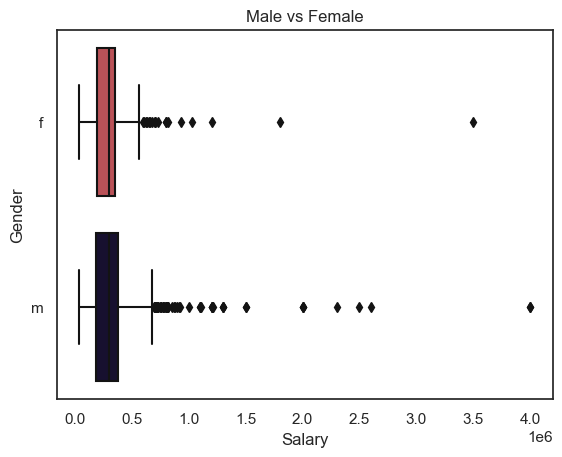

In [97]:
sns.set_palette(sns.color_palette(cmap_Gender1))
sns.boxplot(x=df2.Salary, y=df2.Gender, data=df2).set(title="Male vs Female")

In [98]:
alpha=0.05
t_val, p_value = stats.ttest_ind(male_salary, female_salary)
p_value_onetail = p_value/2
print("t_value = {} , p_value ={} , p_value_onetail = {}".format(t_val, p_value, p_value_onetail))

t_value = 2.1591696882415574 , p_value =0.03091638149374018 , p_value_onetail = 0.01545819074687009


In [99]:
# Enter your code and run the cell
if p_value <alpha:
    print("Conclusion: since p_value {} is less than alpha {} ". format (p_value_onetail,alpha))
    print("Reject the null hypothesis that the average salary of females are less than or equal to males.")
    
else:
    print("Conclusion: since p_value {} is greater than alpha {} ". format (p_value_onetail,alpha))
    print("Fail to reject the null hypothesis that the average salary of females are less than males.")

Conclusion: since p_value 0.01545819074687009 is less than alpha 0.05 
Reject the null hypothesis that the average salary of females are less than or equal to males.


## Hypothesis Testing 2 

$ 𝐻_{0}:\mu_{1}-\mu_{2} = 0 $ There is no difference between the collegeGPA of graduates from CollegeTier 1 and CollegeTier 2. \
$ 𝐻_{A}:\mu_{1}-\mu_{2} != 0 $ There is difference between the collegeGPA of graduates from CollegeTier 1 and CollegeTier 2.

## Hypothesis Testing 3 

$ 𝐻_{0}:\mu_{1}=\mu_{2}=\mu_{3} $ The mean Salary of graduates from every Degree are the same. \
$ 𝐻_{A}: $ At least one of the Degrees's salary is not the same.
